Title: Contribution_RL_Days.ipynb

Purpose: Look how the different components (wind, solar, demand) contribute to the residual load days

Author: Onno Nennecke on 03.09.2025 Modified: 24.09.2025

Input data: 

- Combined model output: model_output_adj.nc
    - This file lies here: /climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc

Output data:

- Plot: 
    - This file lies here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib import colors, cm
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection

In [2]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'
files = [path]

ds = xr.open_dataset(path)

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()

# ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
# ds_ERA5.load()

# ds_SMARD = ds.where(ds.ESM_run == 'SMARD_hist', drop=True)
# ds_SMARD.load()
# ts_datasets

<xarray.Dataset> Size: 42MB
Dimensions:            (ESM_run: 100, time: 3650)
Coordinates:
    crs                int64 8B 4326
    gridtype           <U6 24B 'lonlat'
  * time               (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM                (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run                (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
  * ESM_run            (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0...
    country            float64 8B 9.0
    period             (ESM_run) <U4 2kB 'week' 'week' 'week' ... 'week' 'week'
    doy                (time) int64 29kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
Data variables: (12/16)
    temp               (ESM_run, time) float64 3MB 2.862 -0.3492 ... 6.307 3.968
    demand             (ESM_run, time) float64 3MB 1.485e+03 ... 1.471e+03
    sfcWind            (ESM_run, time) float64 3MB 8.056 6.177 ... 10.63 9.856
    rsds               (ESM_run, time) float32 1MB 13.75 24.11 ... 17.57 21.48
    tas                (ESM_run, time) float32 1MB 2.114 -0.7924 ... 6.209 4.354
    tasmax             (ESM_run, time) float32 1MB 4.033 0.7523 ... 7.664 5.364
    ...                 ...
    Netto              (ESM_run, time) float64 3MB -792.1 -923.2 ... -165.9
    Residual_load      (ESM_run, time) float64 3MB 792.1 923.2 ... 64.31 165.9
    solar_prod_adj     (ESM_run, time) float64 3MB -12.15 2.315 ... 0.2677
    total_prod_adj     (ESM_run, time) float64 3MB 647.0 543.7 ... 1.249e+03
    Netto_adjusted     (ESM_run, time) float64 3MB -837.6 -980.6 ... -221.5
    Residual_load_adj  (ESM_run, time) float64 3MB 837.6 980.6 ... 115.4 221.5

In [3]:
# --- 2) Extract the three time series arrays [ESM_run, time] ---
# wind = ts_datasets['wind_off_prod_adj'] + ts_datasets['wind_on_prod_adj']
solar = ts_datasets['solar_prod_adj']
total = ts_datasets['total_prod_adj']
# demand = ts_datasets['demand']
res_load = ts_datasets['Residual_load_adj']
wind = ts_datasets['wind_off_prod'] + ts_datasets['wind_on_prod']
# solar = ts_datasets['solar_prod']
# total = ts_datasets['total_prod']
demand = ts_datasets['demand']
# res_load = ts_datasets['Residual_load']

# Thresholds
wind_thresh = np.quantile(wind.values.flatten(), 0.05)
solar_thresh = np.quantile(solar.values.flatten(), 0.05)
total_thresh = np.quantile(total.values.flatten(), 0.05)
demand_thresh = np.quantile(demand.values.flatten(), 0.95)
res_load_thresh = np.quantile(res_load.values.flatten(), 0.95)

# --- 3) Pull out the doy coordinate for x-axis ---
x = ts_datasets['doy']

# --- 4) Compute the mean winter cycle (averaged over runs & winters) ---
# mean_wind  = wind.groupby(x).mean(dim=['ESM_run','time'])
# mean_solar = solar.groupby(x).mean(dim=['ESM_run','time'])
# mean_total = total.groupby(x).mean(dim=['ESM_run','time'])
# mean_demand = demand.groupby(x).mean(dim=['ESM_run','time'])
# mean_res_load = res_load.groupby(x).mean(dim=['ESM_run','time'])


In [4]:
# Extreme event days:
extreme_res_load = ts_datasets.where(ts_datasets['Residual_load_adj'] > res_load_thresh)
extreme_res_load

<xarray.Dataset> Size: 42MB
Dimensions:            (ESM_run: 100, time: 3650)
Coordinates:
    crs                int64 8B 4326
    gridtype           <U6 24B 'lonlat'
  * time               (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM                (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run                (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
  * ESM_run            (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0...
    country            float64 8B 9.0
    period             (ESM_run) <U4 2kB 'week' 'week' 'week' ... 'week' 'week'
    doy                (time) int64 29kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
Data variables: (12/16)
    temp               (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    demand             (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    sfcWind            (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    rsds               (ESM_run, time) float32 1MB nan nan nan ... nan nan nan
    tas                (ESM_run, time) float32 1MB nan nan nan ... nan nan nan
    tasmax             (ESM_run, time) float32 1MB nan nan nan ... nan nan nan
    ...                 ...
    Netto              (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    Residual_load      (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    solar_prod_adj     (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    total_prod_adj     (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    Netto_adjusted     (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    Residual_load_adj  (ESM_run, time) float64 3MB nan nan nan ... nan nan nan

In [5]:
# 1) Convert dataset to a long DataFrame
df = ts_datasets.to_dataframe().reset_index()   # columns will include ESM_run, time, ESM, run, variables...

df['winter'] = np.where(df['time'].dt.month.isin([10, 11, 12, 1, 2, 3]), 1, 0)

df['wind_total'] = df['wind_off_prod'] + df['wind_on_prod']

# Filter by the threshold
df_winter = df[df['winter'] == 1]

# Drop any remaining rows with NaNs across any column
df_winter = df_winter.dropna(how='any').reset_index(drop=True)

# Filter by the threshold
df_filtered = df[df['Residual_load_adj'] > res_load_thresh]

# Drop any remaining rows with NaNs across any column
df_filtered = df_filtered.dropna(how='any').reset_index(drop=True)


# df_filtered is now a tidy pandas DataFrame: one row per selected event
print(df_filtered.shape)
df_filtered.head()


(18250, 27)


,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,Residual_load_adj,crs,gridtype,ESM,run,country,period,doy,winter,wind_total
0,ACCESS-CM2_r1i1p1f1,2015-01-05,0.245598,1516.886409,4.147174,21.248137,0.787202,1.800007,61.849189,38.052098,...,1423.036821,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,5,1,99.901288
1,ACCESS-CM2_r1i1p1f1,2015-01-07,-3.086905,1557.932764,4.904704,27.715582,-2.206280,-0.751457,32.787723,77.997430,...,1437.904166,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,7,1,110.785153
2,ACCESS-CM2_r1i1p1f1,2015-01-08,-3.234493,1559.748740,3.830855,30.455936,-2.128153,-0.627887,38.036532,25.855025,...,1479.128472,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,8,1,63.891557
3,ACCESS-CM2_r1i1p1f1,2015-01-18,1.290212,1503.988486,2.607071,29.728300,1.512397,2.677035,17.668979,8.302006,...,1469.444224,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,18,1,25.970985
4,ACCESS-CM2_r1i1p1f1,2015-01-19,0.318840,1515.982819,3.103404,33.742901,0.572515,1.431716,10.574485,8.894297,...,1484.203439,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,19,1,19.468783


In [6]:
# Filter by the threshold
df_reverse_filtered = df[df['Residual_load_adj'] < res_load_thresh]

# Drop any remaining rows with NaNs across any column
df_reverse_filtered = df_reverse_filtered.dropna(how='any').reset_index(drop=True)

In [7]:
print('All Demand min: ', df['demand'].min())
print('All Demand max: ', df['demand'].max())
print('All Demand range: ', df['demand'].max() - df['demand'].min())

print('VRES days Demand min: ', df_filtered['demand'].min())
print('VRES days Demand max: ', df_filtered['demand'].max())
print('VRES days Demand range: ', df_filtered['demand'].max() - df_filtered['demand'].min())

print('Demand VRES days % of All:', (df['demand'].max() - df_filtered['demand'].min()) / (df['demand'].max() - df['demand'].min()) * 100, '\n')

print('All Solar production min: ', df['solar_prod_adj'].min())
print('All Solar production max: ', df['solar_prod_adj'].max())
print('All Solar production range: ', df['solar_prod_adj'].max() - df['solar_prod_adj'].min())

print('VRES days Solar production min: ', df_filtered['solar_prod_adj'].min())
print('VRES days Solar production max: ', df_filtered['solar_prod_adj'].max())
print('VRES days Solar production range: ', df_filtered['solar_prod_adj'].max() - df_filtered['solar_prod_adj'].min())

print('Solar VRES days % of All:', df_filtered['solar_prod_adj'].max() / df['solar_prod_adj'].max() * 100, '\n')

print('All Wind production min: ', df['wind_total'].min())
print('All Wind production max: ', df['wind_total'].max())
print('All Wind production range: ', df['wind_total'].max() - df['wind_total'].min())

print('VRES days Wind production min: ', df_filtered['wind_total'].min())
print('VRES days Wind production max: ', df_filtered['wind_total'].max())
print('VRES days Wind production range: ', df_filtered['wind_total'].max() - df_filtered['wind_total'].min())

print('Wind VRES days % of All:', df_filtered['wind_total'].max() / df['wind_total'].max() * 100, '\n')

All Demand min:  1320.5014457353493
All Demand max:  1702.5083202511773
All Demand range:  382.00687451582803
VRES days Demand min:  1406.7347284766943
VRES days Demand max:  1702.5083202511773
VRES days Demand range:  295.77359177448307
Demand VRES days % of All: 77.42624845413037 

All Solar production min:  -30.450668529465883
All Solar production max:  395.14008036413867
All Solar production range:  425.59074889360454
VRES days Solar production min:  -23.91566799591844
VRES days Solar production max:  188.43870443100408
VRES days Solar production range:  212.3543724269225
Solar VRES days % of All: 47.689088957351444 

All Wind production min:  0.0
All Wind production max:  1743.0216004079998
All Wind production range:  1743.0216004079998
VRES days Wind production min:  0.0
VRES days Wind production max:  252.82061351116312
VRES days Wind production range:  252.82061351116312
Wind VRES days % of All: 14.504732095803277 



In [8]:
print('Solar all:', df['solar_prod_adj'].max())
print('Wind all:', df['wind_total'].max())
print('Demand all:', df['demand'].min())

print('Solar VRES days:', df_filtered['solar_prod_adj'].max())
print('Wind VRES days:', df_filtered['wind_total'].max())
print('Demand VRES days:', df_filtered['demand'].min())

print('Solar Winter:', df_winter['solar_prod_adj'].max())
print('Wind Winter:', df_winter['wind_total'].max())
print('Demand Winter:', df_winter['demand'].min())

# Calculate percentage of Max VRES days compared to all
print('Solar VRES days % of All:', df_filtered['solar_prod_adj'].max() / df['solar_prod_adj'].max() * 100)
print('Wind VRES days % of All:', df_filtered['wind_total'].max() / df['wind_total'].max() * 100)
print('Demand VRES days % of All:', df_filtered['demand'].min() / df['demand'].min() * 100)

Solar all: 395.14008036413867
Wind all: 1743.0216004079998
Demand all: 1320.5014457353493
Solar VRES days: 188.43870443100408
Wind VRES days: 252.82061351116312
Demand VRES days: 1406.7347284766943
Solar Winter: 270.81668817033
Wind Winter: 1743.0216004079998
Demand Winter: 1320.5014528367155
Solar VRES days % of All: 47.689088957351444
Wind VRES days % of All: 14.504732095803277
Demand VRES days % of All: 106.53034368268519


### Density curves

/tmp/ipykernel_1249011/1381070761.py:82: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)  # make room for the legend


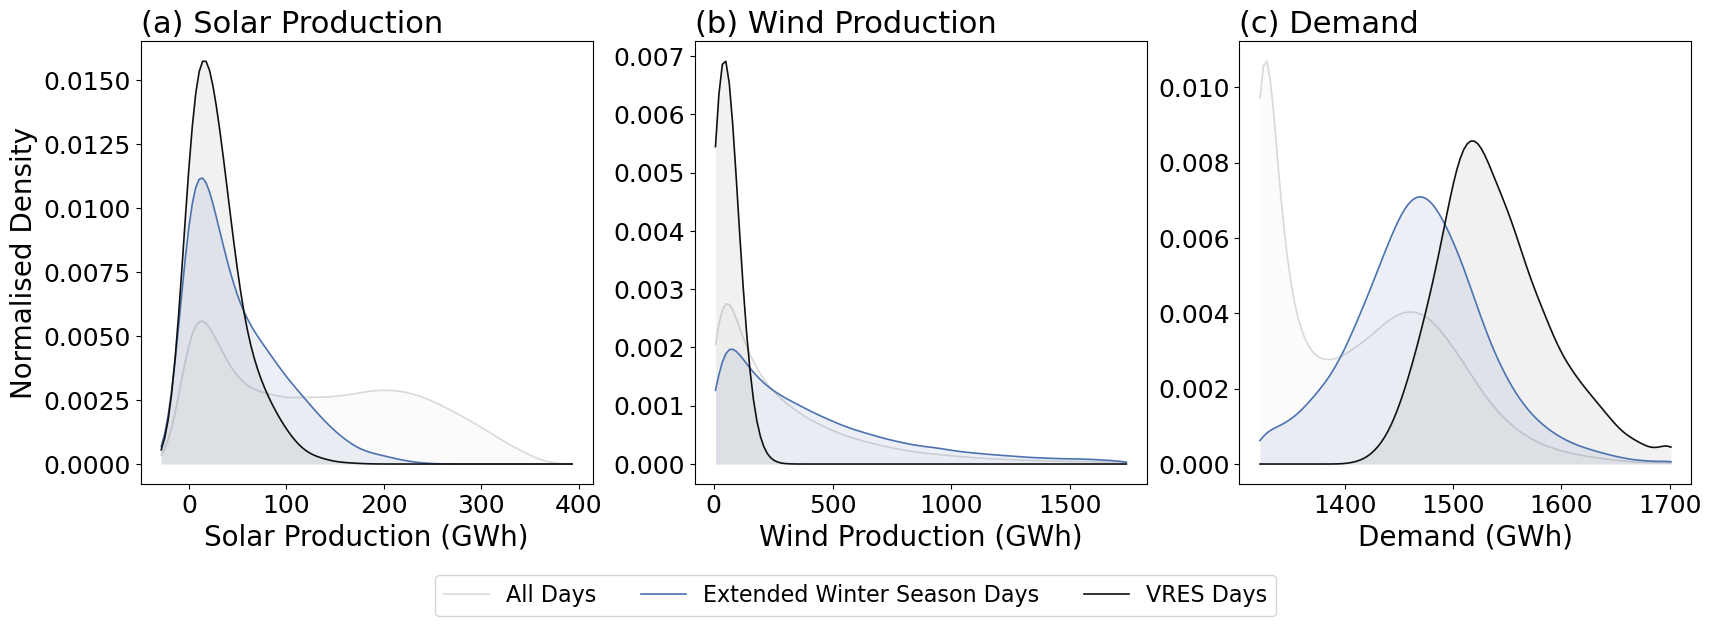

In [ ]:
# variables and appearance
columns = [('solar_prod_adj','(a) Solar Production', 'Solar Production (GWh)'), ('wind_total','(b) Wind Production', 'Wind Production (GWh)'), ('demand','(c) Demand', 'Demand (GWh)')]  # cols and pretty names
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (17,5.5)  # figure size
color_all, color_winter, color_filtered = '#d9d9d9','#4c72b0','#111111'  # colors
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------


# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+4,
    'figure.titlesize': 18+4,
})


fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)  # 3 subplots in a row

for ax, (col, title, xaxis) in zip(axes, columns):
    a = df[col].values  # all data array
    w = df_winter[col].values  # winter array
    f = df_filtered[col].values  # filtered/high-RL array

    # common bin edges spanning min..max across all 3 sets so curves align
    combined_min = min(a.min(), w.min(), f.min())  # global min
    combined_max = max(a.max(), w.max(), f.max())  # global max
    edges = np.linspace(combined_min, combined_max, bins+1)  # bin edges
    centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

    # histogram densities (density=True -> density per unit)
    ca, _ = np.histogram(a, bins=edges, density=True)  # density for all
    cw, _ = np.histogram(w, bins=edges, density=True)  # density for winter
    cf, _ = np.histogram(f, bins=edges, density=True)  # density for filtered

    # smooth densities by convolving with the gaussian kernel
    sa = np.convolve(ca, kernel, mode='same')  # smoothed all
    sw = np.convolve(cw, kernel, mode='same')  # smoothed winter
    sf = np.convolve(cf, kernel, mode='same')  # smoothed filtered

    # normalize each curve to its own peak so every curve's max == 1
    # sa /= max(sa.max(), 1e-12)  # normalize all
    # sw /= max(sw.max(), 1e-12)  # normalize winter
    # sf /= max(sf.max(), 1e-12)  # normalize filtered

    # plotting curves + fills
    ax.plot(centers, sa, lw=lw, color=color_all, label='All', zorder=1)  # all curve
    ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

    ax.plot(centers, sw, lw=lw, color=color_winter, label='Winter', zorder=2)  # winter curve
    ax.fill_between(centers, sw, 0, color=color_winter, alpha=fill_alpha, linewidth=0)  # fill winter

    ax.plot(centers, sf, lw=lw, color=color_filtered, label='VRES', zorder=3)  # filtered curve
    ax.fill_between(centers, sf, 0, color=color_filtered, alpha=0.06, linewidth=0)  # fill filtered

    # labels and styling
    ax.set_title(title, loc='left')  # subplot title
    ax.set_xlabel(xaxis)  # x label
    if ax == axes[0]:
        ax.set_ylabel('Normalised Density')  # y label    ax.grid(True, linestyle=':', alpha=0.4)  # grid
    # ax.legend(fontsize='small')  # legend

# fig.suptitle('Smoothed distributions — All / Winter / VRES (each peak = 1)', y=1.04, fontsize=18)  # overall title

legend_handles = [
    Line2D([0], [0], color=color_all, lw=lw, label='All Days'),
    Line2D([0], [0], color=color_winter, lw=lw, label='Extended Winter Season Days'),
    Line2D([0], [0], color=color_filtered, lw=lw, label='VRES Days'),
]
fig.subplots_adjust(bottom=0.18)  # make room for the legend
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.13), fontsize=16, frameon=True)

# plt.savefig('/home/onennecke/Code/Figures/Contr_RL_Days_dens_curves_0.png', bbox_inches='tight', dpi=300)

plt.show()  # display

### No density curves!

/tmp/ipykernel_181913/915834242.py:82: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)  # make room for the legend


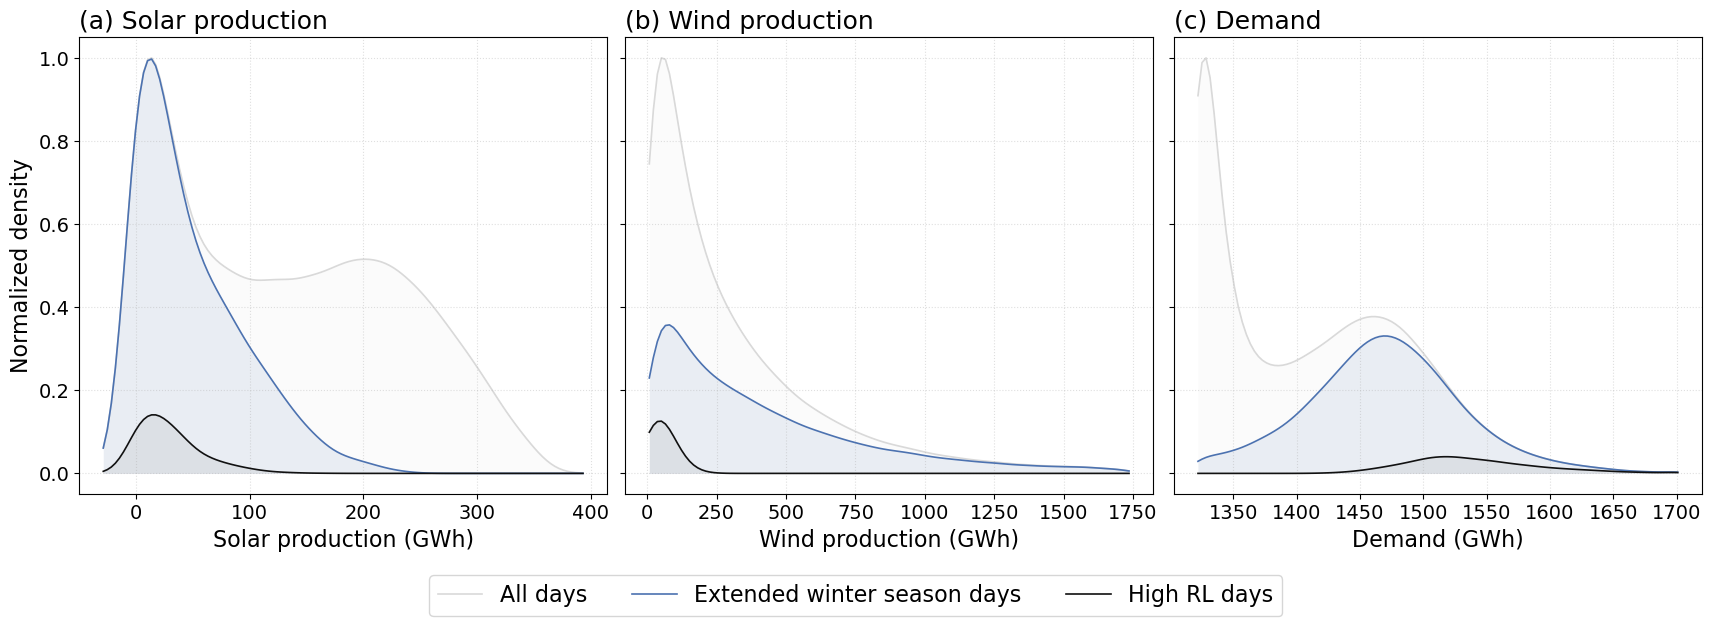

In [ ]:
# variables and appearance
columns = [('solar_prod_adj','(a) Solar production', 'Solar production (GWh)'), ('wind_total','(b) Wind production', 'Wind production (GWh)'), ('demand','(c) Demand', 'Demand (GWh)')]  # cols and pretty names
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (17,5.5)  # figure size
color_all, color_winter, color_filtered = '#d9d9d9','#4c72b0','#111111'  # colors
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------


# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# plotting
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=True)  # 3 subplots in a row

for ax, (col, title, xaxis) in zip(axes, columns):
    a = df[col].values  # all data array
    w = df_winter[col].values  # winter array
    f = df_filtered[col].values  # filtered/high-RL array

    # common bin edges spanning min..max across all 3 sets so curves align
    combined_min = min(a.min(), w.min(), f.min())  # global min
    combined_max = max(a.max(), w.max(), f.max())  # global max
    edges = np.linspace(combined_min, combined_max, bins+1)  # bin edges
    centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

    # histogram counts (density=False -> raw counts) computed on the same edges
    ca, _ = np.histogram(a, bins=edges, density=False)  # counts for all
    cw, _ = np.histogram(w, bins=edges, density=False)  # counts for winter
    cf, _ = np.histogram(f, bins=edges, density=False)  # counts for filtered

    # smooth counts by convolving with the gaussian kernel
    sa = np.convolve(ca, kernel, mode='same')  # smoothed all
    sw = np.convolve(cw, kernel, mode='same')  # smoothed winter
    sf = np.convolve(cf, kernel, mode='same')  # smoothed filtered

    # normalize so the largest peak among the three equals 1 (same as your original)
    peak = max(sa.max(), sw.max(), sf.max(), 1e-12)  # avoid division by zero
    sa /= peak  # normalized all
    sw /= peak  # normalized winter
    sf /= peak  # normalized filtered

    # plotting curves + fills
    ax.plot(centers, sa, lw=lw, color=color_all, label='All', zorder=1)  # all curve
    ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

    ax.plot(centers, sw, lw=lw, color=color_winter, label='Winter', zorder=2)  # winter curve
    ax.fill_between(centers, sw, 0, color=color_winter, alpha=fill_alpha, linewidth=0)  # fill winter

    ax.plot(centers, sf, lw=lw, color=color_filtered, label='VRES', zorder=3)  # filtered curve
    ax.fill_between(centers, sf, 0, color=color_filtered, alpha=0.06, linewidth=0)  # fill filtered

    # labels and styling
    ax.set_title(title, loc='left')  # subplot title
    ax.set_xlabel(xaxis)  # x label
    if ax == axes[0]:
        ax.set_ylabel('Normalized density')  # y label
    ax.grid(True, linestyle=':', alpha=0.4)  # grid
    # ax.legend(fontsize='small')  # legend

legend_handles = [
    Line2D([0], [0], color=color_all, lw=lw, label='All days'),
    Line2D([0], [0], color=color_winter, lw=lw, label='Extended winter season days'),
    Line2D([0], [0], color=color_filtered, lw=lw, label='VRES days'),
]
fig.subplots_adjust(bottom=0.18)  # make room for the legend
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.13), fontsize=16, frameon=True)

# slightly larger suptitle
# fig.suptitle('Smoothed distributions', y=1.04, fontsize=18)

# fig.suptitle('Smoothed distributions', y=1.04, fontsize=14)  # overall title

# plt.savefig('/home/onennecke/Code/Figures/Contr_RL_Days_dens_curves_1.png', bbox_inches='tight', dpi=300)

plt.show()  # display


Was bedeutet das:

1. Alle niedrigen Solarwerte sind im Winter
2. Es gibt keine VRES Tage mit hoher Sonnenproduktion, aber die ist auch nicht zwangsläufig ganz niedrig (Kurve wesentlich breiter als bei Wind)
3. Die Verteilung der VRES Tage hat ist ähnlich zu der winter Kurve (etwas verschoben) 
3. Beim Wind ist es anders herum, da sind alle hohen Werte im Winter, es gibt aber auch einige niedrige im Winter
4. Kein VRES Tag hat eine hohe Windproduktion
5. Demand Kurve mit allen Werten hat viele niedrige Werte, und einige in der Mitte
6. Alle Hohen sind im Winter
7. Die VRES Verteilung ist noch höher geshiftet als die des Winters, aber auch hier kommen mittlere Werte vor

/tmp/ipykernel_181913/133579852.py:83: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)  # make room for the legend


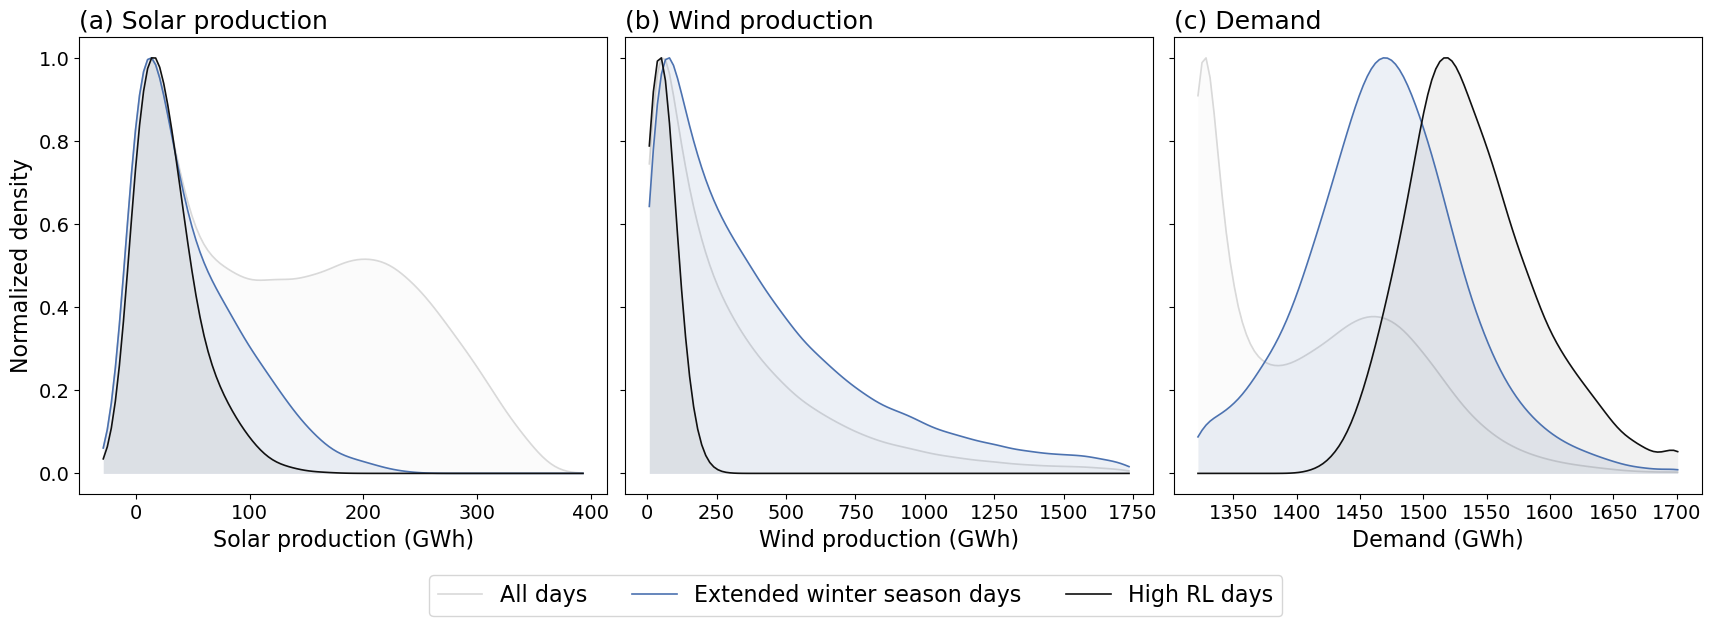

In [ ]:
# variables and appearance
columns = [('solar_prod_adj','(a) Solar production', 'Solar production (GWh)'), ('wind_total','(b) Wind production', 'Wind production (GWh)'), ('demand','(c) Demand', 'Demand (GWh)')]  # cols and pretty names
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (17,5.5)  # figure size
color_all, color_winter, color_filtered = '#d9d9d9','#4c72b0','#111111'  # colors
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------


# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})


# plotting
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=True)  # 3 subplots in a row

for ax, (col, title, xaxis) in zip(axes, columns):
    a = df[col].values  # all data array
    w = df_winter[col].values  # winter array
    f = df_filtered[col].values  # filtered/high-RL array

    # common bin edges spanning min..max across all 3 sets so curves align
    combined_min = min(a.min(), w.min(), f.min())  # global min
    combined_max = max(a.max(), w.max(), f.max())  # global max
    edges = np.linspace(combined_min, combined_max, bins+1)  # bin edges
    centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

    # histogram densities (density=True -> density per unit)
    ca, _ = np.histogram(a, bins=edges, density=True)  # density for all
    cw, _ = np.histogram(w, bins=edges, density=True)  # density for winter
    cf, _ = np.histogram(f, bins=edges, density=True)  # density for filtered

    # smooth densities by convolving with the gaussian kernel
    sa = np.convolve(ca, kernel, mode='same')  # smoothed all
    sw = np.convolve(cw, kernel, mode='same')  # smoothed winter
    sf = np.convolve(cf, kernel, mode='same')  # smoothed filtered

    # normalize each curve to its own peak so every curve's max == 1
    sa /= max(sa.max(), 1e-12)  # normalize all
    sw /= max(sw.max(), 1e-12)  # normalize winter
    sf /= max(sf.max(), 1e-12)  # normalize filtered

    # plotting curves + fills
    ax.plot(centers, sa, lw=lw, color=color_all, label='All', zorder=1)  # all curve
    ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

    ax.plot(centers, sw, lw=lw, color=color_winter, label='Winter', zorder=2)  # winter curve
    ax.fill_between(centers, sw, 0, color=color_winter, alpha=fill_alpha, linewidth=0)  # fill winter

    ax.plot(centers, sf, lw=lw, color=color_filtered, label='VRES', zorder=3)  # filtered curve
    ax.fill_between(centers, sf, 0, color=color_filtered, alpha=0.06, linewidth=0)  # fill filtered

    # labels and styling
    ax.set_title(title, loc='left')  # subplot title
    ax.set_xlabel(xaxis)  # x label
    if ax == axes[0]:
        ax.set_ylabel('Normalized density')  # y label    ax.grid(True, linestyle=':', alpha=0.4)  # grid
    # ax.legend(fontsize='small')  # legend

# fig.suptitle('Smoothed distributions — All / Winter / VRES (each peak = 1)', y=1.04, fontsize=18)  # overall title

legend_handles = [
    Line2D([0], [0], color=color_all, lw=lw, label='All days'),
    Line2D([0], [0], color=color_winter, lw=lw, label='Extended winter season days'),
    Line2D([0], [0], color=color_filtered, lw=lw, label='VRES days'),
]
fig.subplots_adjust(bottom=0.18)  # make room for the legend
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.13), fontsize=16, frameon=True)

# plt.savefig('/home/onennecke/Code/Figures/Contr_RL_Days_dens_curves_2.png', bbox_inches='tight', dpi=300)

plt.show()  # display


### Normalization stuff

In [11]:
def normalize_series(arr, method='percentile', robust=False):
    """Return normalized array in [0..1] for percentile/minmax, or zscore for zscore methods."""
    a = np.asarray(arr, dtype=float)
    if method == 'percentile':
        # rank-based percentile (0..1)
        # handle NaN by leaving them as NaN
        sr = pd.Series(a)
        pct = sr.rank(method='average', pct=True)  # 0..1
        return pct.to_numpy()
    elif method == 'minmax':
        mn, mx = np.nanmin(a), np.nanmax(a)
        if mx == mn:
            return np.zeros_like(a)
        return (a - mn) / (mx - mn)
    elif method == 'zscore':
        if robust:
            med = np.nanmedian(a)
            mad = np.nanmedian(np.abs(a - med))
            if mad == 0:
                return np.zeros_like(a)
            return (a - med) / (1.4826 * mad)  # robust z (not bounded)
        else:
            mu = np.nanmean(a)
            sd = np.nanstd(a, ddof=0)
            if sd == 0:
                return np.zeros_like(a)
            return (a - mu) / sd
    else:
        raise ValueError("method must be 'percentile', 'minmax' or 'zscore'")

In [12]:
solar_all = df['solar_prod_adj']
df['solar_norm'] = 1 - normalize_series(solar_all, method='percentile')
wind_all = df['wind_off_prod'] + df['wind_on_prod']
df['wind_norm'] = 1 - normalize_series(wind_all, method='percentile')
demand_all = df['demand']
df['demand_norm'] = normalize_series(demand_all, method='percentile')

# 2) Filter by the threshold
df_filtered = df[df['Residual_load_adj'] > res_load_thresh]

# 3) Drop any remaining rows with NaNs across any column (optional, but you said "without nan values")
df_filtered = df_filtered.dropna(how='any').reset_index(drop=True)

In [13]:
df.columns

Index(['ESM_run', 'time', 'temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax',
       'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Netto',
       'Residual_load', 'solar_prod_adj', 'total_prod_adj', 'Netto_adjusted',
       'Residual_load_adj', 'crs', 'gridtype', 'ESM', 'run', 'country',
       'period', 'doy', 'winter', 'wind_total', 'solar_norm', 'wind_norm',
       'demand_norm'],
      dtype='object')

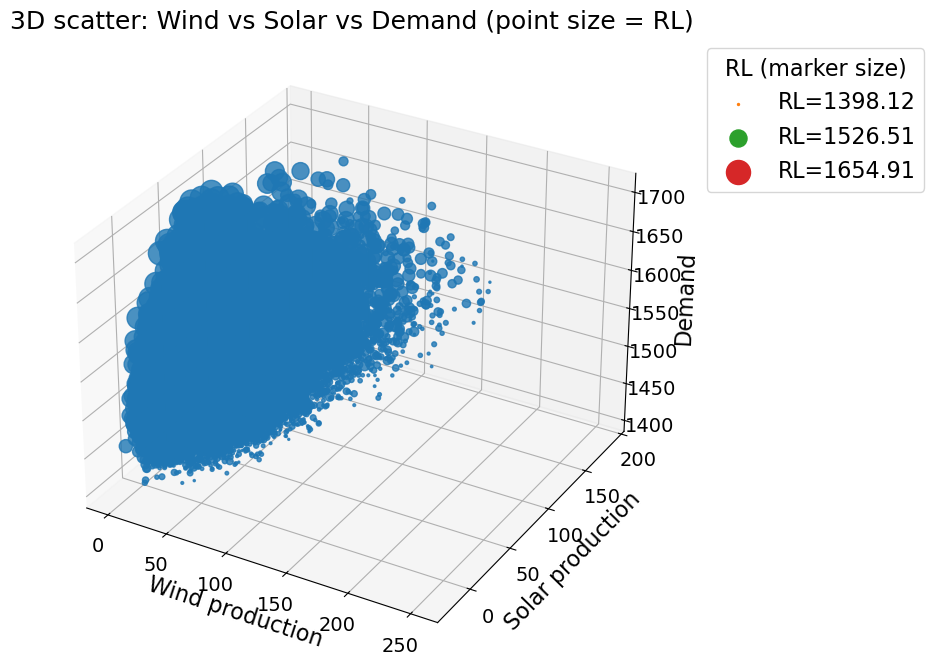

In [14]:
# 3d_scatter_matplotlib.py

def plot_wind_solar_demand_matplotlib(
    df,
    wind_col='wind',
    solar_col='solar',
    demand_col='demand',
    rl_col='rl',
    size_min=2,
    size_max=300,
    figsize=(9, 7)
):
    """
    Create a 3D scatter:
      x = wind_col, y = solar_col, z = demand_col
      marker size scaled from rl_col between size_min and size_max.
    If savepath is provided, the figure is saved there.
    """
    x = df[wind_col].to_numpy()
    y = df[solar_col].to_numpy()
    z = df[demand_col].to_numpy()
    rl = df[rl_col].to_numpy()

    # scale RL to marker sizes (area)
    rl_min, rl_max = rl.min(), rl.max()
    if rl_max == rl_min:
        sizes = np.full_like(rl, (size_min + size_max) / 2, dtype=float)
    else:
        sizes = size_min + (rl - rl_min) / (rl_max - rl_min) * (size_max - size_min)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(x, y, z, s=sizes, alpha=0.8)

    ax.set_xlabel('Wind production')
    ax.set_ylabel('Solar production')
    ax.set_zlabel('Demand')
    ax.set_title('3D scatter: Wind vs Solar vs Demand (point size = RL)')

    # Add a simple legend using example RL values
    example_rl = np.linspace(rl_min, rl_max, 3)
    example_sizes = size_min + (example_rl - rl_min) / max((rl_max - rl_min), 1) * (size_max - size_min)
    for erl, esize in zip(example_rl, example_sizes):
        ax.scatter([], [], [], s=esize, label=f'RL={erl:.2f}')
    ax.legend(title='RL (marker size)', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()



plot_wind_solar_demand_matplotlib(df_filtered, wind_col='wind_total', solar_col='solar_prod_adj', demand_col='demand', rl_col='Residual_load_adj')

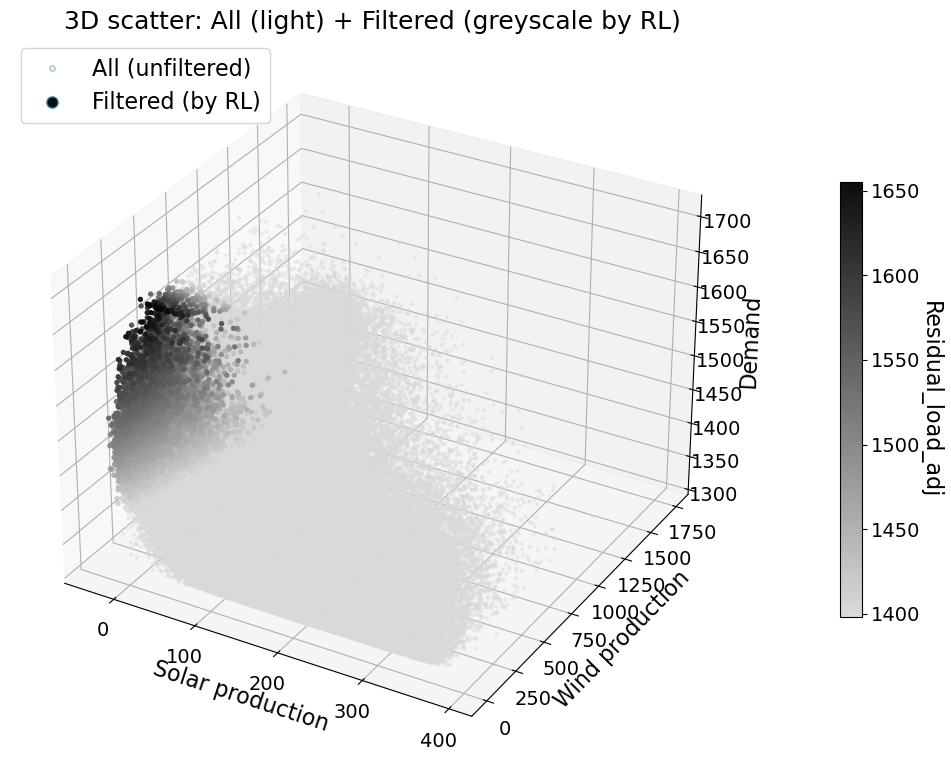

In [15]:
# Column names you want to plot
x_col = 'solar_prod_adj'
y_col = 'wind_total'
z_col = 'demand'
rl_col = 'Residual_load_adj'  # used only for the filtered dataset

# --- Parameters for appearance ---
# Marker sizes (fixed, NOT mapped to RL)
size_unfiltered = 4     # very small light-grey points
size_filtered = 8      # main points colored by RL

alpha_unfiltered = 0.35
alpha_filtered = 0.95

figsize = (11, 8)

# <-- CHANGED LINES: use a custom greyscale that starts at a light grey instead of white
# create a linear colormap from light grey (not white) to black
cmap = colors.LinearSegmentedColormap.from_list('custom_greys', ['#d9d9d9', '#000000'])
# -------------------------------------------------------------------------------

# --- Extract arrays for plotting ---
x_all = df[x_col].to_numpy()
y_all = df[y_col].to_numpy()
z_all = df[z_col].to_numpy()

x_f = df_filtered[x_col].to_numpy()
y_f = df_filtered[y_col].to_numpy()
z_f = df_filtered[z_col].to_numpy()
rl = df_filtered[rl_col].to_numpy()

# Optional: drop NaNs so scatter doesn't complain
mask_all = ~np.isnan(x_all) & ~np.isnan(y_all) & ~np.isnan(z_all)
x_all, y_all, z_all = x_all[mask_all], y_all[mask_all], z_all[mask_all]

mask_f = ~np.isnan(x_f) & ~np.isnan(y_f) & ~np.isnan(z_f) & ~np.isnan(rl)
x_f, y_f, z_f, rl = x_f[mask_f], y_f[mask_f], z_f[mask_f], rl[mask_f]

# --- Normalize RL for the colormap ---
rl_min, rl_max = np.nanmin(rl), np.nanmax(rl)
if rl_max == rl_min:
    # avoid zero-range normalization — make a tiny range so mapping works
    rl_vmin, rl_vmax = rl_min - 0.5, rl_max + 0.5
else:
    rl_vmin, rl_vmax = rl_min, rl_max

norm = colors.Normalize(vmin=rl_vmin, vmax=rl_vmax)

# Determine the lightest colour used by the colormap at the RL minimum
light_grey_for_minRL = cmap(norm(rl_vmin))  # this will be the same light tone the filtered points will use at minimum RL

# -------------------------
# Plotting
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# 1) Plot all/unfiltered points as very small, light-grey dots
ax.scatter(
    x_all, y_all, z_all,
    s=size_unfiltered,
    c=[light_grey_for_minRL],  # single light color
    alpha=alpha_unfiltered,
    depthshade=True,
    label='All (unfiltered)'
)

# 2) Plot filtered points colored by RL (light -> dark)
sc = ax.scatter(
    x_f, y_f, z_f,
    s=size_filtered,
    c=rl,
    cmap=cmap,
    norm=norm,
    alpha=alpha_filtered,
    depthshade=True,
    label='Filtered (colored by RL)'
)

# Colorbar for RL
cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label(rl_col, rotation=270, labelpad=15)

# Axis labels and title
ax.set_ylabel('Wind production')
ax.set_xlabel('Solar production')
ax.set_zlabel('Demand')
ax.set_title('3D scatter: All (light) + Filtered (greyscale by RL)')

# Optional: legend (note legend handles 3D scatter proxies; here we add simple proxies)
from matplotlib.lines import Line2D
proxy_all = Line2D([0], [0], linestyle='none', marker='o',
                   markersize=4, markerfacecolor=light_grey_for_minRL, alpha=alpha_unfiltered)
proxy_filtered = Line2D([0], [0], linestyle='none', marker='o',
                        markersize=8, markerfacecolor='0.0', alpha=alpha_filtered)  # black proxy for legend
ax.legend([proxy_all, proxy_filtered], ['All (unfiltered)', 'Filtered (by RL)'], loc='upper left')

plt.tight_layout()
plt.show()

/tmp/ipykernel_181913/397743386.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


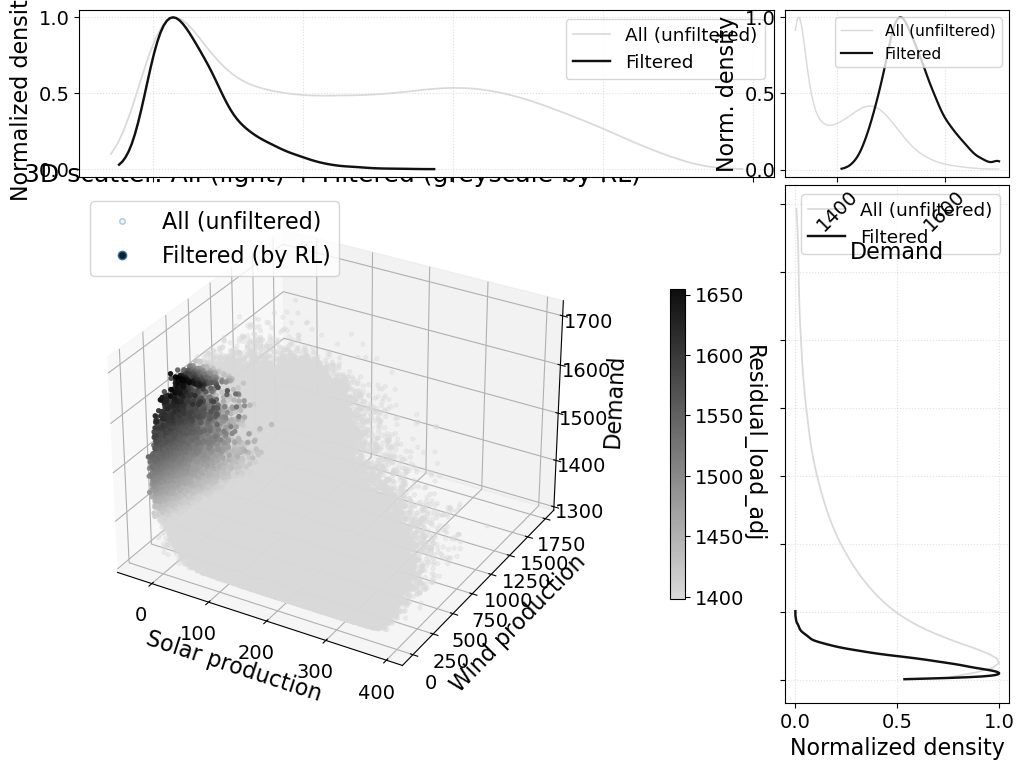

In [16]:
# two_layer_3d_scatter_with_marginals.py


# Column names you want to plot
x_col = 'solar_prod_adj'
y_col = 'wind_total'
z_col = 'demand'
rl_col = 'Residual_load_adj'  # used only for the filtered dataset

# --- Parameters for appearance ---
# Marker sizes (fixed, NOT mapped to RL)
size_unfiltered = 8     # very small light-grey points
size_filtered = 8       # main points colored by RL

alpha_unfiltered = 0.35
alpha_filtered = 0.95

figsize = (12, 9)

# custom greyscale that starts at a light grey instead of white
cmap = colors.LinearSegmentedColormap.from_list('custom_greys', ['#d9d9d9', '#000000'])

# Colors for marginal curves
unfiltered_curve_color = '#d9d9d9'  # same light grey
filtered_curve_color = '#111111'    # almost black for filtered curve

# --- Extract arrays for plotting ---
x_all = df[x_col].to_numpy()
y_all = df[y_col].to_numpy()
z_all = df[z_col].to_numpy()

x_f = df_filtered[x_col].to_numpy()
y_f = df_filtered[y_col].to_numpy()
z_f = df_filtered[z_col].to_numpy()
rl = df_filtered[rl_col].to_numpy()

# Optional: drop NaNs so scatter doesn't complain
mask_all = ~np.isnan(x_all) & ~np.isnan(y_all) & ~np.isnan(z_all)
x_all, y_all, z_all = x_all[mask_all], y_all[mask_all], z_all[mask_all]

mask_f = ~np.isnan(x_f) & ~np.isnan(y_f) & ~np.isnan(z_f) & ~np.isnan(rl)
x_f, y_f, z_f, rl = x_f[mask_f], y_f[mask_f], z_f[mask_f], rl[mask_f]

# --- Normalize RL for the colormap (used for point colors in the main scatter) ---
rl_min, rl_max = np.nanmin(rl), np.nanmax(rl)
if rl_max == rl_min:
    rl_vmin, rl_vmax = rl_min - 0.5, rl_max + 0.5
else:
    rl_vmin, rl_vmax = rl_min, rl_max
norm = colors.Normalize(vmin=rl_vmin, vmax=rl_vmax)

# Determine the lightest colour used by the colormap at the RL minimum
light_grey_for_minRL = cmap(0.0)  # 0 maps to the first color '#d9d9d9'

# -------------------------
# Helper: compute a smoothed histogram/density-like curve (no scipy dependency)
def smoothed_density_curve(values, num_bins=100, smooth_sigma=2):
    """
    Return bin_centers, smoothed_counts (normalized so max=1).
    Uses numpy.histogram and gaussian smoothing by convolution.
    """
    vals = np.asarray(values)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return np.array([]), np.array([])

    counts, edges = np.histogram(vals, bins=num_bins, density=False)
    centers = (edges[:-1] + edges[1:]) / 2

    # Gaussian kernel
    sigma = smooth_sigma
    kernel_width = int(np.clip(3 * sigma, 1, 50))
    kernel_x = np.arange(-kernel_width, kernel_width + 1)
    kernel = np.exp(-0.5 * (kernel_x / sigma) ** 2)
    kernel = kernel / kernel.sum()

    smoothed = np.convolve(counts, kernel, mode='same')

    # Normalize so max=1 (keeps scale consistent between curves)
    if smoothed.max() > 0:
        smoothed = smoothed / smoothed.max()
    return centers, smoothed

# -------------------------
# Layout: GridSpec with 4x4 cells
fig = plt.figure(figsize=figsize)
gs = GridSpec(4, 4, figure=fig, wspace=0.05, hspace=0.05)

# Main 3D scatter in rows 1:4, cols 0:3
ax_main = fig.add_subplot(gs[1:4, 0:3], projection='3d')

# Top marginal (x axis distribution) at row 0, cols 0:3
ax_x = fig.add_subplot(gs[0, 0:3], sharex=None)

# Right marginal (y axis distribution) at rows 1:4, col 3
ax_y = fig.add_subplot(gs[1:4, 3], sharey=None)

# Corner marginal (z axis distribution) at row 0, col 3
ax_z = fig.add_subplot(gs[0, 3])

# -------------------------
# 1) Plot all/unfiltered points as very small, light-grey dots in main 3D scatter
ax_main.scatter(
    x_all, y_all, z_all,
    s=size_unfiltered,
    c=[light_grey_for_minRL],
    alpha=alpha_unfiltered,
    depthshade=True,
    label='All (unfiltered)'
)

# 2) Plot filtered points colored by RL (light -> dark)
sc = ax_main.scatter(
    x_f, y_f, z_f,
    s=size_filtered,
    c=rl,
    cmap=cmap,
    norm=norm,
    alpha=alpha_filtered,
    depthshade=True,
    label='Filtered (colored by RL)'
)

# Colorbar for RL (attach to main axis)
cbar = fig.colorbar(sc, ax=ax_main, pad=0.12, shrink=0.6)
cbar.set_label(rl_col, rotation=270, labelpad=15)

# Axis labels and title
ax_main.set_xlabel('Solar production')
ax_main.set_ylabel('Wind production')
ax_main.set_zlabel('Demand')
ax_main.set_title('3D scatter: All (light) + Filtered (greyscale by RL)')

# -------------------------
# Marginal: X (solar) distribution - above the main plot
centers_x_all, curve_x_all = smoothed_density_curve(x_all, num_bins=100, smooth_sigma=3)
centers_x_f, curve_x_f = smoothed_density_curve(x_f, num_bins=100, smooth_sigma=3)

ax_x.plot(centers_x_all, curve_x_all, lw=1.25, label='All (unfiltered)', color=unfiltered_curve_color)
ax_x.plot(centers_x_f, curve_x_f, lw=1.75, label='Filtered', color=filtered_curve_color)
ax_x.set_ylabel('Normalized density')
ax_x.tick_params(axis='x', labelbottom=False)  # hide x labels to avoid clutter
ax_x.grid(True, linestyle=':', alpha=0.4)
ax_x.legend(loc='upper right', fontsize='small')

# Marginal: Y (wind) distribution - to the right of main (plot horizontally)
centers_y_all, curve_y_all = smoothed_density_curve(y_all, num_bins=100, smooth_sigma=3)
centers_y_f, curve_y_f = smoothed_density_curve(y_f, num_bins=100, smooth_sigma=3)

# For the right plot we want density horizontally and values vertically:
ax_y.plot(curve_y_all, centers_y_all, lw=1.25, color=unfiltered_curve_color, label='All (unfiltered)')
ax_y.plot(curve_y_f, centers_y_f, lw=1.75, color=filtered_curve_color, label='Filtered')
ax_y.set_xlabel('Normalized density')
ax_y.tick_params(axis='y', labelleft=False)  # hide y labels to avoid clutter
ax_y.grid(True, linestyle=':', alpha=0.4)
ax_y.legend(loc='upper right', fontsize='small')

# Marginal: Z (demand) distribution - small corner plot
centers_z_all, curve_z_all = smoothed_density_curve(z_all, num_bins=100, smooth_sigma=3)
centers_z_f, curve_z_f = smoothed_density_curve(z_f, num_bins=100, smooth_sigma=3)

ax_z.plot(centers_z_all, curve_z_all, lw=1.0, color=unfiltered_curve_color, label='All (unfiltered)')
ax_z.plot(centers_z_f, curve_z_f, lw=1.6, color=filtered_curve_color, label='Filtered')
ax_z.set_xlabel('Demand')
ax_z.set_ylabel('Norm. density')
ax_z.tick_params(axis='x', labelrotation=45)
ax_z.grid(True, linestyle=':', alpha=0.4)
ax_z.legend(loc='upper right', fontsize='x-small')

# Tidy up margins: remove tick labels where appropriate to reduce clutter
plt.setp(ax_x.get_xticklabels(), visible=False)
plt.setp(ax_y.get_yticklabels(), visible=False)

# Optional: proxies for legend in the 3D main axis (keeps legend appearance similar to earlier)
proxy_all = Line2D([0], [0], linestyle='none', marker='o',
                   markersize=4, markerfacecolor=unfiltered_curve_color, alpha=alpha_unfiltered)
proxy_filtered = Line2D([0], [0], linestyle='none', marker='o',
                        markersize=6, markerfacecolor=filtered_curve_color, alpha=alpha_filtered)
ax_main.legend([proxy_all, proxy_filtered], ['All (unfiltered)', 'Filtered (by RL)'], loc='upper left')

plt.tight_layout()
plt.show()


/tmp/ipykernel_181913/2488602043.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Greys')  # reversed greys: 0 -> light, 1 -> dark


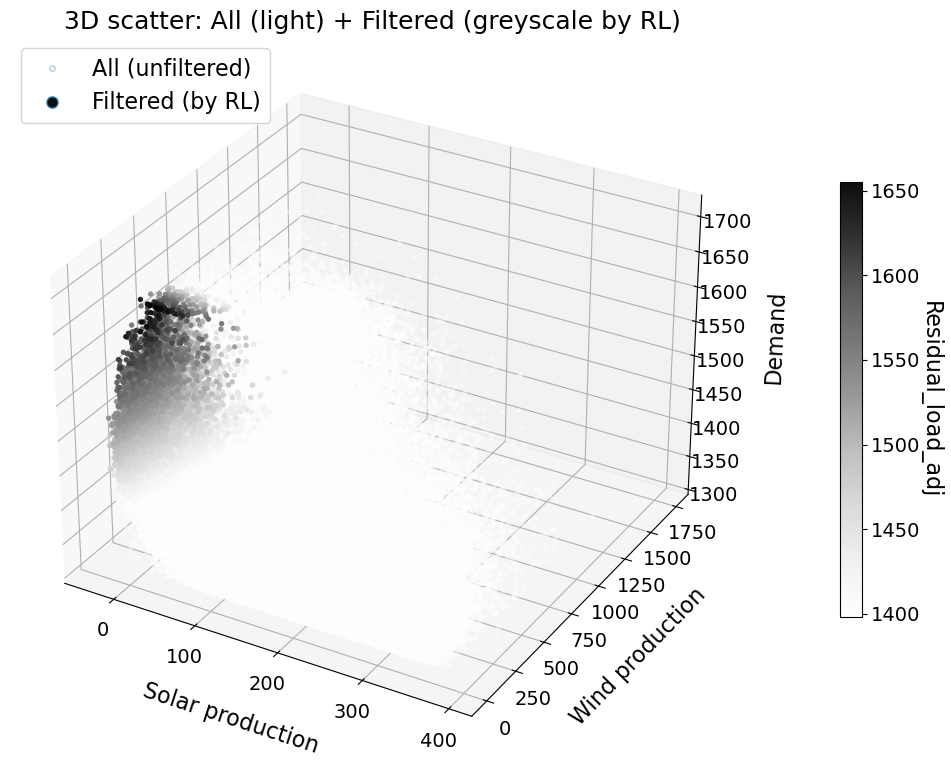

In [17]:


# Column names you want to plot
x_col = 'solar_prod_adj'
y_col = 'wind_total'
z_col = 'demand'
rl_col = 'Residual_load_adj'  # used only for the filtered dataset

# --- Parameters for appearance ---
# Marker sizes (fixed, NOT mapped to RL)
size_unfiltered = 8     # very small light-grey points
size_filtered = 8      # main points colored by RL

alpha_unfiltered = 0.35
alpha_filtered = 0.95

figsize = (11, 8)
cmap = cm.get_cmap('Greys')  # reversed greys: 0 -> light, 1 -> dark

# --- Extract arrays for plotting ---
x_all = df[x_col].to_numpy()
y_all = df[y_col].to_numpy()
z_all = df[z_col].to_numpy()

x_f = df_filtered[x_col].to_numpy()
y_f = df_filtered[y_col].to_numpy()
z_f = df_filtered[z_col].to_numpy()
rl = df_filtered[rl_col].to_numpy()

# Optional: drop NaNs so scatter doesn't complain
mask_all = ~np.isnan(x_all) & ~np.isnan(y_all) & ~np.isnan(z_all)
x_all, y_all, z_all = x_all[mask_all], y_all[mask_all], z_all[mask_all]

mask_f = ~np.isnan(x_f) & ~np.isnan(y_f) & ~np.isnan(z_f) & ~np.isnan(rl)
x_f, y_f, z_f, rl = x_f[mask_f], y_f[mask_f], z_f[mask_f], rl[mask_f]

# --- Normalize RL for the colormap ---
rl_min, rl_max = np.nanmin(rl), np.nanmax(rl)
if rl_max == rl_min:
    # avoid zero-range normalization — make a tiny range so mapping works
    rl_vmin, rl_vmax = rl_min - 0.5, rl_max + 0.5
else:
    rl_vmin, rl_vmax = rl_min, rl_max

norm = colors.Normalize(vmin=rl_vmin, vmax=rl_vmax)

# Determine the lightest colour used by the colormap at the RL minimum
light_grey_for_minRL = cmap(norm(rl_vmin))  # this will be the same light tone the filtered points will use at minimum RL

# -------------------------
# Plotting
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# 1) Plot all/unfiltered points as very small, light-grey dots
ax.scatter(
    x_all, y_all, z_all,
    s=size_unfiltered,
    c=[light_grey_for_minRL],  # single light color
    alpha=alpha_unfiltered,
    # marker='o',
    depthshade=True,
    label='All (unfiltered)'
)

# 2) Plot filtered points colored by RL (light -> dark)
sc = ax.scatter(
    x_f, y_f, z_f,
    s=size_filtered,
    c=rl,
    cmap=cmap,
    norm=norm,
    alpha=alpha_filtered,
    # marker='o',
    depthshade=True,
    label='Filtered (colored by RL)'
)

# Colorbar for RL
cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label(rl_col, rotation=270, labelpad=15)

# Axis labels and title
ax.set_ylabel('Wind production', labelpad=15)
ax.set_xlabel('Solar production', labelpad=15)
ax.set_zlabel('Demand', labelpad=15)
ax.set_title('3D scatter: All (light) + Filtered (greyscale by RL)')

# Optional: legend (note legend handles 3D scatter proxies; here we add simple proxies)
proxy_all = Line2D([0], [0], linestyle='none', marker='o',
                   markersize=4, markerfacecolor=light_grey_for_minRL, alpha=alpha_unfiltered)
proxy_filtered = Line2D([0], [0], linestyle='none', marker='o',
                        markersize=8, markerfacecolor='0.0', alpha=alpha_filtered)  # black proxy for legend
ax.legend([proxy_all, proxy_filtered], ['All (unfiltered)', 'Filtered (by RL)'], loc='upper left')

plt.tight_layout()
plt.show()


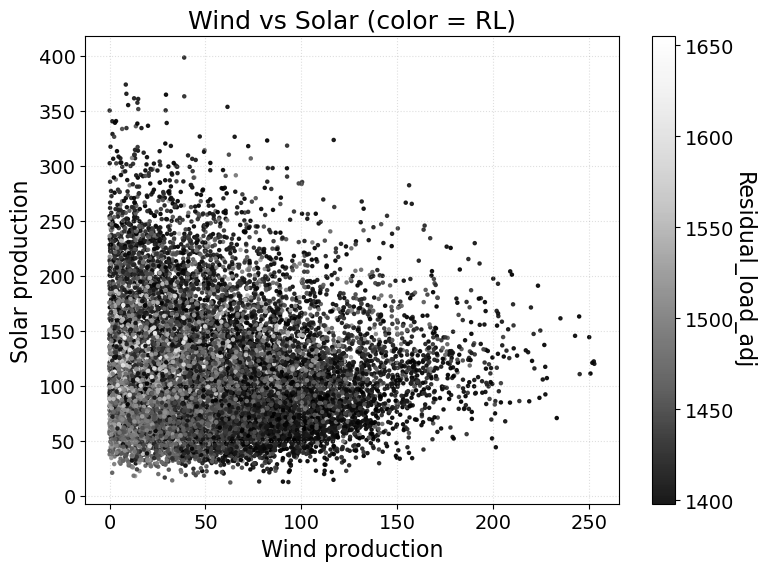

In [18]:

def plot_wind_solar_2d(
    df,
    wind_col='wind',
    solar_col='solar',
    rl_col='rl',
    cmap='Greys_r',   # reversed greys: low -> light, high -> dark
    marker_size=5,
    alpha=0.9,
    figsize=(8,6)
):
    """
    2D scatter: x=wind_col, y=solar_col, color mapped to rl_col (light -> dark).
    """
    x = df[wind_col].to_numpy()
    y = df[solar_col].to_numpy()
    c = df[rl_col].to_numpy()

    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(x, y, c=c, cmap=cmap, s=marker_size, alpha=alpha)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(rl_col, rotation=270, labelpad=15)

    ax.set_xlabel('Wind production')
    ax.set_ylabel('Solar production')
    ax.set_title('Wind vs Solar (color = RL)')
    ax.grid(True, linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.show()


plot_wind_solar_2d(df_filtered, wind_col='wind_total', solar_col='solar_prod', rl_col='Residual_load_adj')


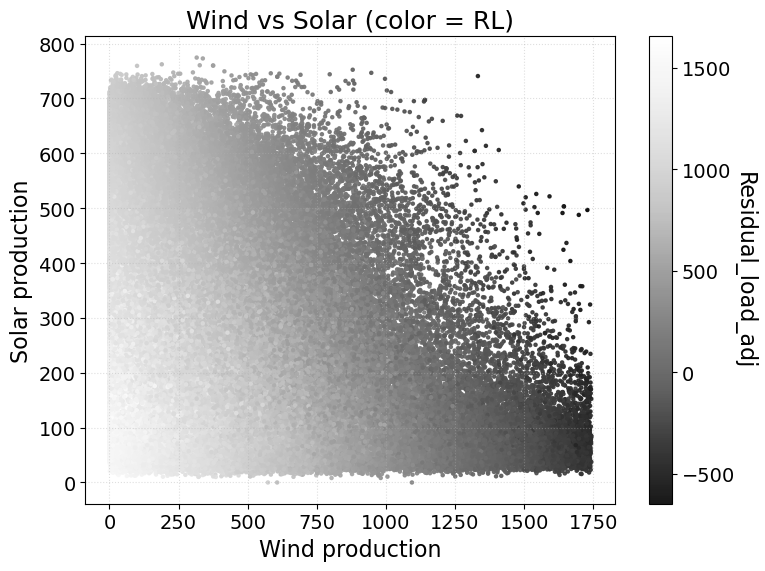

In [19]:
plot_wind_solar_2d(df, wind_col='wind_total', solar_col='solar_prod', rl_col='Residual_load_adj')


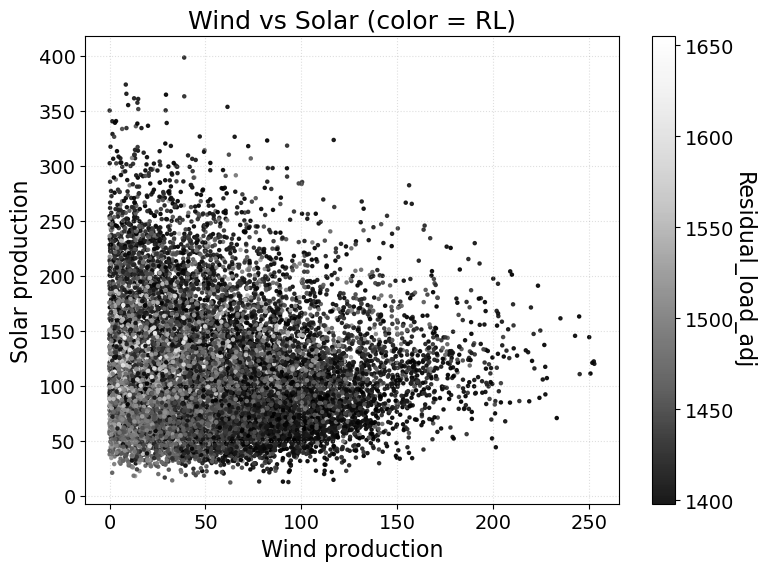

In [20]:

plot_wind_solar_2d(df_filtered, wind_col='wind_total', solar_col='solar_prod', rl_col='Residual_load_adj')


In [3]:
cmap='Greys_r'
marker_size=5
alpha=0.9
figsize=(8,6)
x = df['wind_total'].to_numpy()
y = df['solar_prod'].to_numpy()
c = df['Residual_load_adj'].to_numpy()

fig, ax = plt.subplots(figsize=figsize)
sc = ax.scatter(x, y, c=c, cmap=cmap, s=marker_size, alpha=alpha)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Residual_load_adj', rotation=270, labelpad=15)

ax.set_xlabel('Wind production')
ax.set_ylabel('Solar production')
ax.set_title('Wind vs Solar (color = RL)')
ax.grid(True, linestyle=':', alpha=0.4)

# plt.tight_layout()
# plt.show()



# --- Extract arrays (use the same DataFrame/column names that exist) ---
x = df_filtered['wind_total'].to_numpy()
y = df_filtered['solar_prod'].to_numpy()
c = df_filtered['Residual_load_adj'].to_numpy()

# --- Plot ---
sc = ax.scatter(x, y, c=c, cmap=cmap, s=marker_size, alpha=alpha)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Residual_load_adj', rotation=270, labelpad=15)

ax.set_xlabel('Wind production')
ax.set_ylabel('Solar production')
ax.set_title('Wind vs Solar (color = RL)')
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [2]:
cmap='Greys_r'
marker_size=5
alpha=0.9
figsize=(8,6)
x = df['wind_total'].to_numpy()
y = df['solar_prod'].to_numpy()
c = df['Residual_load'].to_numpy()

fig, ax = plt.subplots(figsize=figsize)
sc = ax.scatter(x, y, c=c, cmap=cmap, s=marker_size, alpha=alpha)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Residual_load', rotation=270, labelpad=15)

ax.set_xlabel('Wind production')
ax.set_ylabel('Solar production')
ax.set_title('Wind vs Solar (color = RL)')
ax.grid(True, linestyle=':', alpha=0.4)

# plt.tight_layout()
# plt.show()



# --- Extract arrays (use the same DataFrame/column names that exist) ---
x = df_filtered['wind_total'].to_numpy()
y = df_filtered['solar_prod'].to_numpy()
c = df_filtered['Residual_load'].to_numpy()

# --- Plot ---
sc = ax.scatter(x, y, c=c, cmap=cmap, s=marker_size, alpha=alpha)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Residual_load', rotation=270, labelpad=15)

ax.set_xlim(0, 1900)
ax.set_ylim(0, 1900)

ax.set_xlabel('Wind production')
ax.set_ylabel('Solar production')
ax.set_title('Wind vs Solar (color = RL)')
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

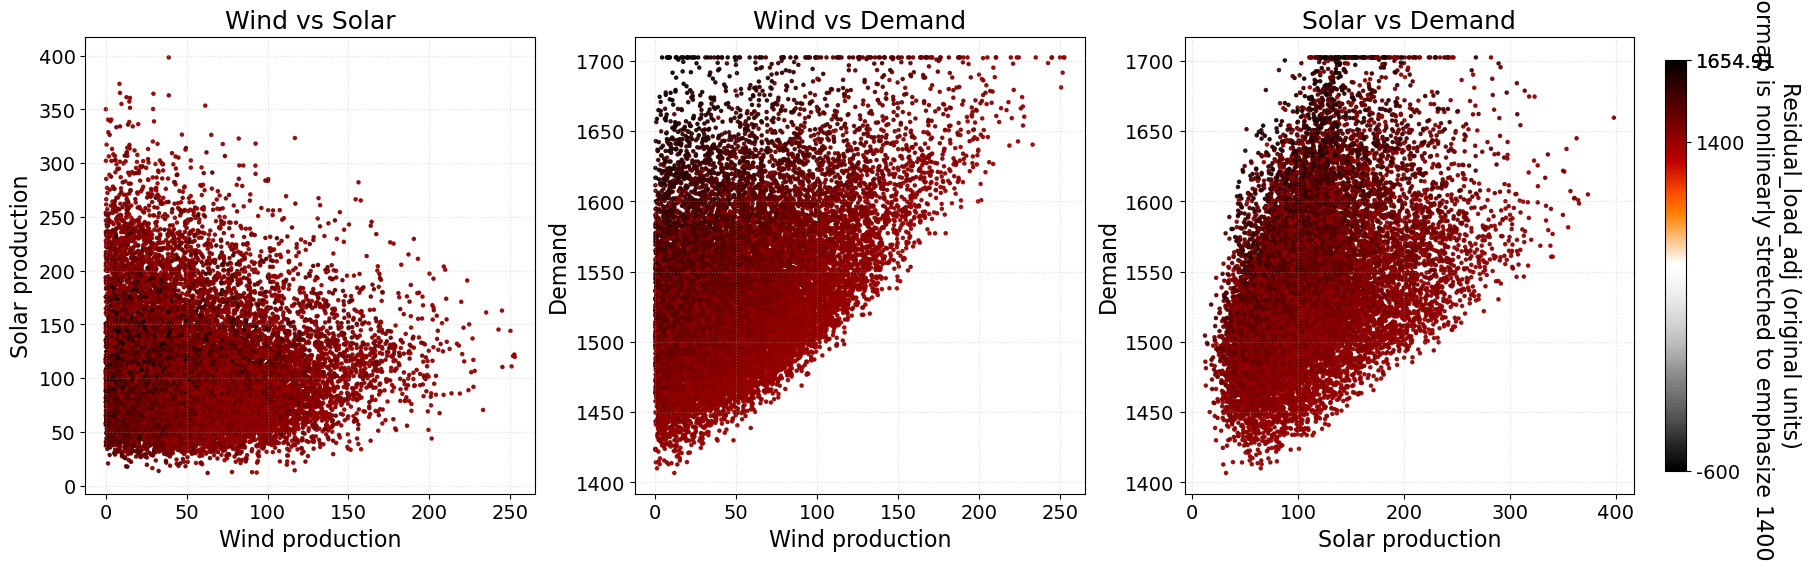

In [24]:


# --- user-tweakable parameters ------------------------------------------------
marker_size = 5
alpha = 0.9
figsize = (18, 5.5)           # 3 plots side-by-side
cmap_lower = plt.cm.Greys_r  # colormap for lower/bulk range
cmap_upper = plt.cm.gist_heat_r  # colormap for emphasized upper range

# RL stretch parameters (change if you want a different emphasized subrange)
low = -600      # left-most value shown (mapped -> 0)
mid1 = 1400     # end of bulk range (mapped -> 0.8)
mid2 = 1650     # end of emphasized range (mapped -> 1.0)
# ------------------------------------------------------------------------------

# build combined colormap (128 from each -> 256 colors)
colors1 = cmap_lower(np.linspace(0.0, 1.0, 128))
colors2 = cmap_upper(np.linspace(0.0, 1.0, 128))
colors = np.vstack((colors1, colors2))
combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_rl", colors)

# scaling function: map original RL values -> [0,1] nonlinearly
def scale_rl(c, low=low, mid1=mid1, mid2=mid2):
    c = np.asarray(c, dtype=float)
    scaled = np.zeros_like(c, dtype=float)

    # region 1: <= low -> 0
    mask = c <= low
    scaled[mask] = 0.0

    # region 2: low < c <= mid1 -> linear to [0, 0.8]
    mask = (c > low) & (c <= mid1)
    scaled[mask] = ((c[mask] - low) / (mid1 - low)) * 0.8

    # region 3: mid1 < c <= mid2 -> linear to [0.8, 1.0]
    mask = (c > mid1) & (c <= mid2)
    scaled[mask] = 0.8 + ((c[mask] - mid1) / (mid2 - mid1)) * 0.2

    # region 4: > mid2 -> 1.0
    mask = c > mid2
    scaled[mask] = 1.0

    # NaNs remain NaN
    scaled[np.isnan(c)] = np.nan
    return scaled

# prepare data arrays (drop NaNs for plotting but keep mapping consistent)
x1 = df_filtered['wind_total'].to_numpy()
y1 = df_filtered['solar_prod'].to_numpy()
x2 = df_filtered['wind_total'].to_numpy()
y2 = df_filtered['demand'].to_numpy()
x3 = df_filtered['solar_prod'].to_numpy()
y3 = df_filtered['demand'].to_numpy()
c_orig = df_filtered['Residual_load_adj'].to_numpy()

# compute scaled color values
c_scaled = scale_rl(c_orig)

# create figure and axes
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)

pairs = [
    (x1, y1, 'Wind production', 'Solar production', 'Wind vs Solar'),
    (x2, y2, 'Wind production', 'Demand', 'Wind vs Demand'),
    (x3, y3, 'Solar production', 'Demand', 'Solar vs Demand'),
]

# plot each subplot using the SAME scaled c values and same colormap (vmin=0, vmax=1)
for ax, (xx, yy, xlabel, ylabel, title) in zip(axes, pairs):
    # mask rows where x or y or color is nan
    mask = np.isfinite(xx) & np.isfinite(yy) & np.isfinite(c_scaled)
    sc = ax.scatter(xx[mask], yy[mask], c=c_scaled[mask], cmap=combined_cmap,
                    s=marker_size, alpha=alpha, vmin=0.0, vmax=1.0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

# build a single colorbar for all three plots (show ticks in original RL units)
# Create a ScalarMappable to feed the colorbar (norm 0..1 because we pre-scaled to 0..1)
mappable = plt.cm.ScalarMappable(cmap=combined_cmap, norm=plt.Normalize(vmin=0.0, vmax=1.0))
mappable.set_array([])  # required for colorbar

# choose tick positions in original RL units and convert to normalized positions
data_max = np.nanmax(c_orig)
tick_vals = [low, mid1, mid2, max(mid2, data_max)]
tick_norms = scale_rl(np.array(tick_vals))
cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_ticks(tick_norms)
cbar.set_ticklabels([f'{v:g}' for v in tick_vals])
cbar.set_label('Residual_load_adj (original units)\n(note: colormap is nonlinearly stretched to emphasize 1400–1650)', rotation=270, labelpad=18)

plt.show()


In [11]:
df_filtered[(df_filtered['run'] == 'ERA5_week')]

,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,Residual_load_adj,crs,gridtype,ESM,run,country,period,doy,winter,wind_total


In [13]:
# Pick ERA5_week ESM and 06.11.2024
df_filtered_CS = df_filtered[(df_filtered['ESM'] == 'ERA5_week') & (df_filtered['time'] == '2024-11-06')]
df_filtered_CS

,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,Residual_load_adj,crs,gridtype,ESM,run,country,period,doy,winter,wind_total
9668,ERA5_hist_week,2024-11-06,5.629105,1449.888193,0.978996,44.516037,6.096062,7.821702,0.0,0.0,...,1422.102507,4326,lonlat,ERA5_week,hist,9.0,week,310,1,0.0


/tmp/ipykernel_1249011/1657334826.py:160: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax.scatter(


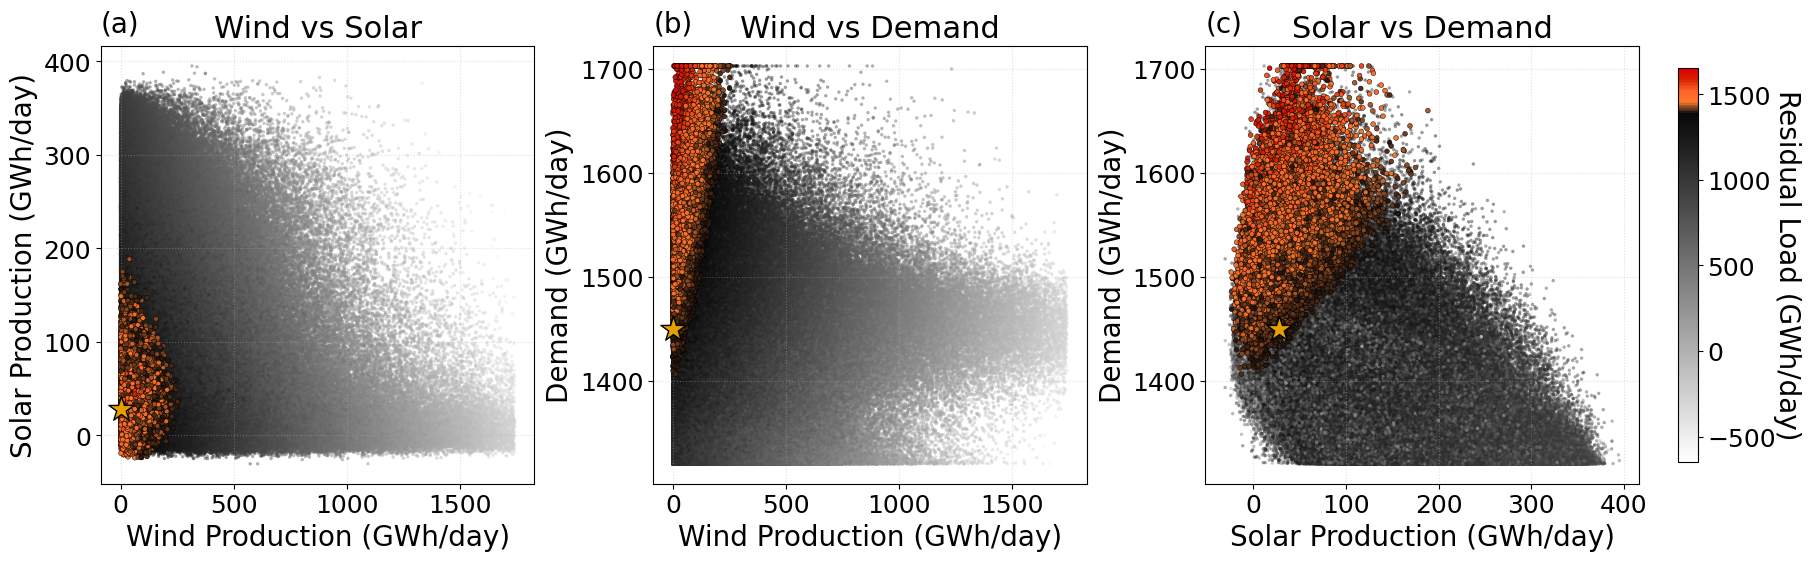

In [14]:


mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+4,
    'figure.titlesize': 18+4,
})


# -------------- user parameters --------------
marker_all = 6
marker_filt = 12
alpha_all = 0.45
alpha_filt = 0.95
figsize = (18, 5.5)

# base colormaps you want to combine
cmap_low = plt.cm.binary        # used for the lower/majority range
# cmap_high = plt.cm.gist_heat_r  # used only for the top portion
# orig = plt.cm.gist_heat_r
# colors = orig(np.linspace(0.0, 1.0, 256))
# # replace the darkest color with a dark red (hex chosen here)
# colors[-1] = mcolors.to_rgba("#bb0000")
# cmap_high = mcolors.LinearSegmentedColormap.from_list('gist_heat_r_darkred_end', colors)

# cmap_high = plt.cm.get_cmap('YlOrRd')  # less custom but also avoids black
cmap_high = mcolors.LinearSegmentedColormap.from_list(
    'yellow_orange_darkred',
    ["#fe8f4f", "#fe7729", "#fe6529", "#d92101", "#df0000"]  # light yellow -> orange -> dark red
)


# fraction of the colormap to reserve for cmap_high (top of the scale)
upper_frac = 0.05   # 0.05 -> top 5% of colors come from cmap_high

# number of discrete colors in combined map (higher -> smoother)
ncolors = 256

# seam blending width in colors (to smooth transition); small integer like 6..12
blend = 8
# ----------------------------------------------

# ------------------ Replace previous colormap-building with this ------------------
# threshold in original Residual_load_adj units (set to the value you want)
threshold = 1398.1161147066591  # <- change this to your desired threshold

# ensure vmin/vmax are available (if not, derive from combined df + df_filtered)
if 'vmin' not in globals() or 'vmax' not in globals():
    c_pool = np.concatenate([
        df['Residual_load_adj'].to_numpy().ravel(),
        df_filtered['Residual_load_adj'].to_numpy().ravel()
    ])
    c_pool = c_pool[np.isfinite(c_pool)]
    if c_pool.size == 0:
        raise RuntimeError("No finite Residual_load_adj values found in df / df_filtered.")
    vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# compute upper_frac from threshold relative to the vmin..vmax range
# if threshold >= vmax -> upper_frac = 0 (no high-colormap)
# if threshold <= vmin -> upper_frac = 1 (all high-colormap)
if vmax <= vmin:
    upper_frac = 0.5  # fallback if degenerate range
else:
    upper_frac = (vmax - threshold) / (vmax - vmin)
    upper_frac = float(np.clip(upper_frac, 0.0, 1.0))

# --- optional alternative: compute fraction based on empirical proportion of points above threshold
# uncomment to use empirical fraction (may be preferable if distribution is skewed)
# c_pool_vals = c_pool  # from above
# upper_frac = np.mean(c_pool_vals >= threshold)

# convert fraction to discrete color counts
n_high = max(2, int(round(upper_frac * ncolors)))
n_low = max(2, ncolors - n_high)
# ensure exact total
if n_low + n_high != ncolors:
    n_low = ncolors - n_high

# sample the two colormaps
colors_low = cmap_low(np.linspace(0.0, 1.0, n_low))
colors_high = cmap_high(np.linspace(0.0, 1.0, n_high))

# create a blended seam to avoid a hard cut (uses `blend` from your config)
if blend > 0:
    b = min(blend, n_low - 1, n_high - 1)
    if b > 0:
        seam_low = colors_low[-b:]
        seam_high = colors_high[:b]
        blended = np.array([ (1 - t) * sl + t * sh for t, sl, sh in zip(np.linspace(0,1,b), seam_low, seam_high) ])
        colors = np.vstack([colors_low[:-b], blended, colors_high[b:]])
    else:
        colors = np.vstack([colors_low, colors_high])
else:
    colors = np.vstack([colors_low, colors_high])

# final combined colormap
combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_top_threshold", colors)
# -----------------------------------------------------------------------------------


# plotting pairs
pairs = [
    ('wind_total', 'solar_prod_adj', 'Wind Production (GWh/day)', 'Solar Production (GWh/day)', 'Wind vs Solar'),
    ('wind_total', 'demand', 'Wind Production (GWh/day)', 'Demand (GWh/day)', 'Wind vs Demand'),
    ('solar_prod_adj', 'demand', 'Solar Production (GWh/day)', 'Demand (GWh/day)', 'Solar vs Demand'),
]

# determine shared vmin/vmax from both dataframes (no scaling)
c_pool = np.concatenate([
    df['Residual_load_adj'].to_numpy().ravel(),
    df_filtered['Residual_load_adj'].to_numpy().ravel()
])
c_pool = c_pool[np.isfinite(c_pool)]
if c_pool.size == 0:
    raise RuntimeError("No finite Residual_load_adj values in df / df_filtered.")
vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# create figure and axes
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, pairs):
    # background: df
    x_all = df[xcol].to_numpy()
    y_all = df[ycol].to_numpy()
    c_all = df['Residual_load_adj'].to_numpy()
    mask_all = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(c_all)
    sc_all = ax.scatter(
        x_all[mask_all], y_all[mask_all],
        c=c_all[mask_all],
        cmap=combined_cmap,
        s=marker_all,
        alpha=alpha_all,
        vmin=vmin, vmax=vmax,
        edgecolors='none', zorder=1
    )
    
    # foreground: df_filtered
    x_f = df_filtered[xcol].to_numpy()
    y_f = df_filtered[ycol].to_numpy()
    c_f = df_filtered['Residual_load_adj'].to_numpy()
    mask_f = np.isfinite(x_f) & np.isfinite(y_f) & np.isfinite(c_f)
    sc_f = ax.scatter(
        x_f[mask_f], y_f[mask_f],
        c=c_f[mask_f],
        cmap=combined_cmap,
        s=marker_filt,
        alpha=alpha_filt,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=0.35, zorder=3
    )
    # ax.set_xlim(min(df['solar_prod_adj'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod_adj'].max(), df['wind_total'].max(), df['demand'].max()))
    # ax.set_ylim(min(df['solar_prod_adj'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod_adj'].max(), df['wind_total'].max(), df['demand'].max()))

    # Set star marker at df_filtered_CS
    x_cs = df_filtered_CS[xcol].to_numpy()
    y_cs = df_filtered_CS[ycol].to_numpy()
    # c_cs = df_filtered_CS['Residual_load_adj'].to_numpy()
    ax.scatter(
        x_cs, y_cs,
        c="#E69F00",
        cmap=combined_cmap,
        s=marker_filt * 30,
        alpha=1.0,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=1.0,
        marker='*',
        zorder=4
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

    # # simple legend for roles (not color)
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', label='All days',
    #            markerfacecolor='gray', markersize=7, alpha=alpha_all),
    #     Line2D([0], [0], marker='o', color='w', label='Filtered / VRES',
    #            markerfacecolor='gray', markeredgecolor='k', markersize=10, alpha=alpha_filt)
    # ]
    # ax.legend(handles=legend_elements, loc='upper right')

# left-aligned, not bold, placed just above each subplot
for i, ax in enumerate(axes):
    label = f'({chr(ord("a") + i)})'
    # y slightly above the axis (1.02); use va='bottom' so text sits above the top edge
    ax.text(0.0, 1.02, label,
            transform=ax.transAxes,
            fontweight='normal',  # not bold
            ha='left',
            va='bottom')

# single shared colorbar (maps numeric RL values to the combined colormap)
mappable = plt.cm.ScalarMappable(cmap=combined_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label('Residual Load (GWh/day)', rotation=270, labelpad=18)

# Save plot
plt.savefig('/home/onennecke/Code/Figures/Sctrplt_composition_marker.png', bbox_inches='tight', dpi=300)

plt.show()


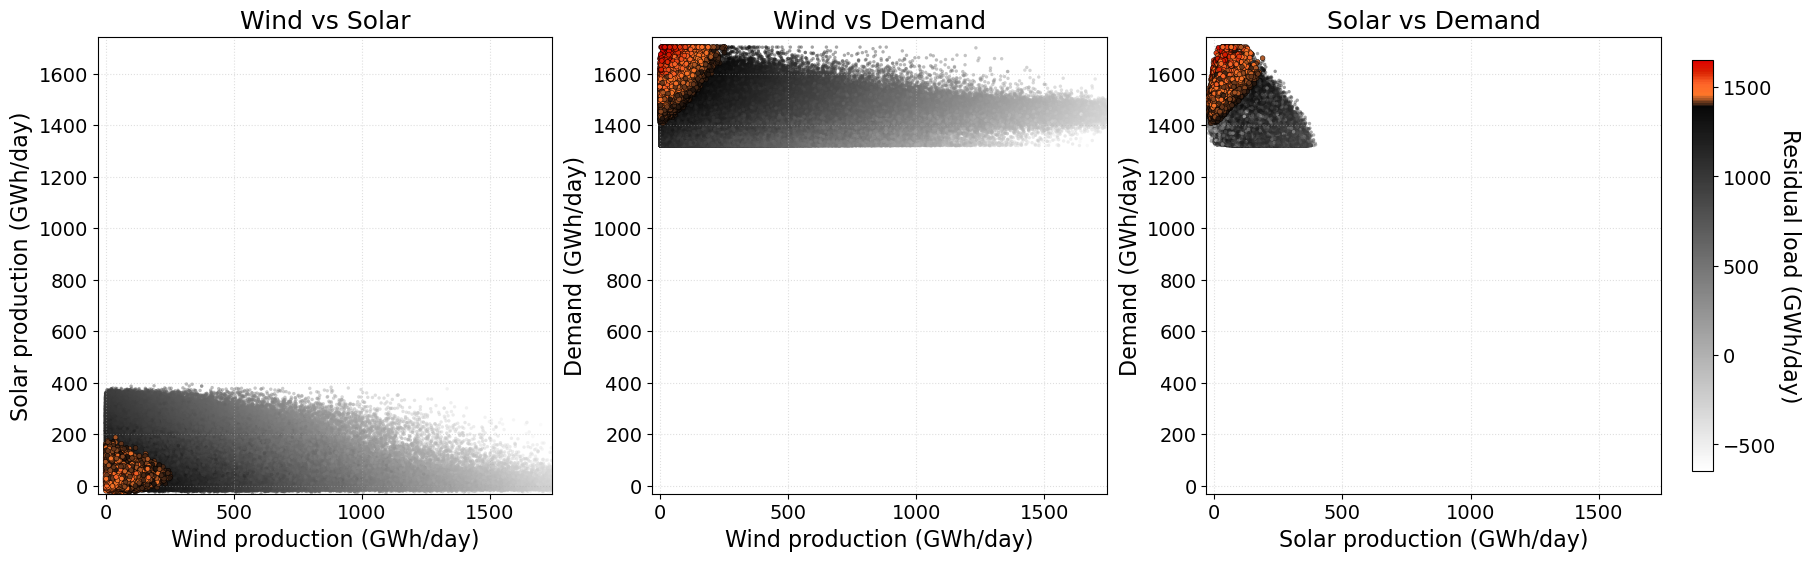

In [ ]:
# -------------- user parameters --------------
marker_all = 6
marker_filt = 12
alpha_all = 0.45
alpha_filt = 0.95
figsize = (18, 5.5)

# base colormaps you want to combine
cmap_low = plt.cm.binary        # used for the lower/majority range
# cmap_high = plt.cm.gist_heat_r  # used only for the top portion
# orig = plt.cm.gist_heat_r
# colors = orig(np.linspace(0.0, 1.0, 256))
# # replace the darkest color with a dark red (hex chosen here)
# colors[-1] = mcolors.to_rgba("#bb0000")
# cmap_high = mcolors.LinearSegmentedColormap.from_list('gist_heat_r_darkred_end', colors)

# cmap_high = plt.cm.get_cmap('YlOrRd')  # less custom but also avoids black
cmap_high = mcolors.LinearSegmentedColormap.from_list(
    'yellow_orange_darkred',
    ["#fe8f4f", "#fe7729", "#fe6529", "#d92101", "#df0000"]  # light yellow -> orange -> dark red
)


# fraction of the colormap to reserve for cmap_high (top of the scale)
upper_frac = 0.05   # 0.05 -> top 5% of colors come from cmap_high

# number of discrete colors in combined map (higher -> smoother)
ncolors = 256

# seam blending width in colors (to smooth transition); small integer like 6..12
blend = 8
# ----------------------------------------------

# ------------------ Replace previous colormap-building with this ------------------
# threshold in original Residual_load_adj units (set to the value you want)
threshold = 1398.1161147066591  # <- change this to your desired threshold

# ensure vmin/vmax are available (if not, derive from combined df + df_filtered)
if 'vmin' not in globals() or 'vmax' not in globals():
    c_pool = np.concatenate([
        df['Residual_load_adj'].to_numpy().ravel(),
        df_filtered['Residual_load_adj'].to_numpy().ravel()
    ])
    c_pool = c_pool[np.isfinite(c_pool)]
    if c_pool.size == 0:
        raise RuntimeError("No finite Residual_load_adj values found in df / df_filtered.")
    vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# compute upper_frac from threshold relative to the vmin..vmax range
# if threshold >= vmax -> upper_frac = 0 (no high-colormap)
# if threshold <= vmin -> upper_frac = 1 (all high-colormap)
if vmax <= vmin:
    upper_frac = 0.5  # fallback if degenerate range
else:
    upper_frac = (vmax - threshold) / (vmax - vmin)
    upper_frac = float(np.clip(upper_frac, 0.0, 1.0))

# --- optional alternative: compute fraction based on empirical proportion of points above threshold
# uncomment to use empirical fraction (may be preferable if distribution is skewed)
# c_pool_vals = c_pool  # from above
# upper_frac = np.mean(c_pool_vals >= threshold)

# convert fraction to discrete color counts
n_high = max(2, int(round(upper_frac * ncolors)))
n_low = max(2, ncolors - n_high)
# ensure exact total
if n_low + n_high != ncolors:
    n_low = ncolors - n_high

# sample the two colormaps
colors_low = cmap_low(np.linspace(0.0, 1.0, n_low))
colors_high = cmap_high(np.linspace(0.0, 1.0, n_high))

# create a blended seam to avoid a hard cut (uses `blend` from your config)
if blend > 0:
    b = min(blend, n_low - 1, n_high - 1)
    if b > 0:
        seam_low = colors_low[-b:]
        seam_high = colors_high[:b]
        blended = np.array([ (1 - t) * sl + t * sh for t, sl, sh in zip(np.linspace(0,1,b), seam_low, seam_high) ])
        colors = np.vstack([colors_low[:-b], blended, colors_high[b:]])
    else:
        colors = np.vstack([colors_low, colors_high])
else:
    colors = np.vstack([colors_low, colors_high])

# final combined colormap
combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_top_threshold", colors)
# -----------------------------------------------------------------------------------


# plotting pairs
pairs = [
    ('wind_total', 'solar_prod_adj', 'Wind production (GWh/day)', 'Solar production (GWh/day)', 'Wind vs Solar'),
    ('wind_total', 'demand', 'Wind production (GWh/day)', 'Demand (GWh/day)', 'Wind vs Demand'),
    ('solar_prod_adj', 'demand', 'Solar production (GWh/day)', 'Demand (GWh/day)', 'Solar vs Demand'),
]

# determine shared vmin/vmax from both dataframes (no scaling)
c_pool = np.concatenate([
    df['Residual_load_adj'].to_numpy().ravel(),
    df_filtered['Residual_load_adj'].to_numpy().ravel()
])
c_pool = c_pool[np.isfinite(c_pool)]
if c_pool.size == 0:
    raise RuntimeError("No finite Residual_load_adj values in df / df_filtered.")
vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# create figure and axes
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, pairs):
    # background: df
    x_all = df[xcol].to_numpy()
    y_all = df[ycol].to_numpy()
    c_all = df['Residual_load_adj'].to_numpy()
    mask_all = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(c_all)
    sc_all = ax.scatter(
        x_all[mask_all], y_all[mask_all],
        c=c_all[mask_all],
        cmap=combined_cmap,
        s=marker_all,
        alpha=alpha_all,
        vmin=vmin, vmax=vmax,
        edgecolors='none', zorder=1
    )

    # foreground: df_filtered
    x_f = df_filtered[xcol].to_numpy()
    y_f = df_filtered[ycol].to_numpy()
    c_f = df_filtered['Residual_load_adj'].to_numpy()
    mask_f = np.isfinite(x_f) & np.isfinite(y_f) & np.isfinite(c_f)
    sc_f = ax.scatter(
        x_f[mask_f], y_f[mask_f],
        c=c_f[mask_f],
        cmap=combined_cmap,
        s=marker_filt,
        alpha=alpha_filt,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=0.35, zorder=3
    )
    ax.set_xlim(min(df['solar_prod_adj'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod_adj'].max(), df['wind_total'].max(), df['demand'].max()))
    ax.set_ylim(min(df['solar_prod_adj'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod_adj'].max(), df['wind_total'].max(), df['demand'].max()))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

    # # simple legend for roles (not color)
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', label='All days',
    #            markerfacecolor='gray', markersize=7, alpha=alpha_all),
    #     Line2D([0], [0], marker='o', color='w', label='Filtered / VRES',
    #            markerfacecolor='gray', markeredgecolor='k', markersize=10, alpha=alpha_filt)
    # ]
    # ax.legend(handles=legend_elements, loc='upper right')

# single shared colorbar (maps numeric RL values to the combined colormap)
mappable = plt.cm.ScalarMappable(cmap=combined_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label('Residual load (GWh/day)', rotation=270, labelpad=18)

plt.show()


In [ ]:
df_reverse_filtered

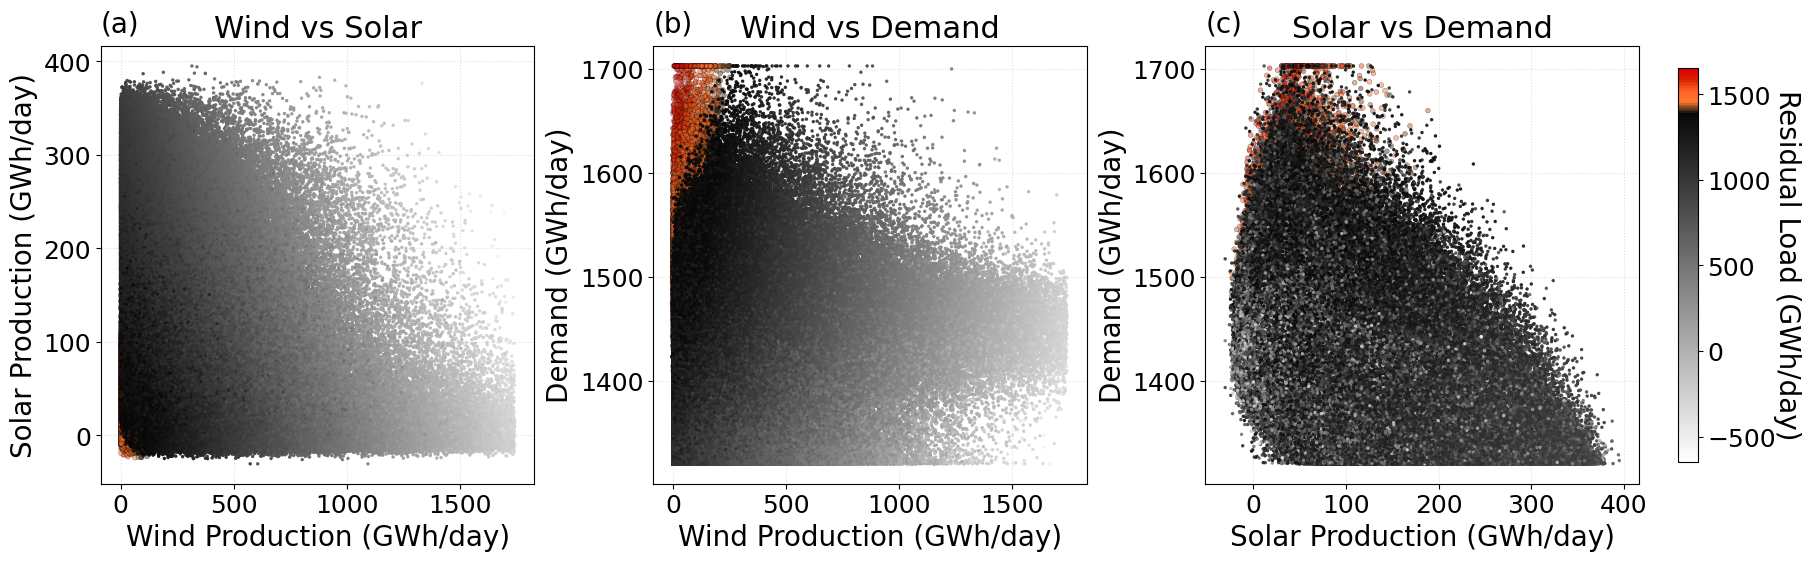

In [15]:

# -------------- user parameters --------------
marker_all = 12
marker_filt = 6
alpha_all = 0.45
alpha_filt = 0.95
figsize = (18, 5.5)

# base colormaps you want to combine
cmap_low = plt.cm.binary        # used for the lower/majority range
# cmap_high = plt.cm.gist_heat_r  # used only for the top portion
# orig = plt.cm.gist_heat_r
# colors = orig(np.linspace(0.0, 1.0, 256))
# # replace the darkest color with a dark red (hex chosen here)
# colors[-1] = mcolors.to_rgba("#bb0000")
# cmap_high = mcolors.LinearSegmentedColormap.from_list('gist_heat_r_darkred_end', colors)

# cmap_high = plt.cm.get_cmap('YlOrRd')  # less custom but also avoids black
cmap_high = mcolors.LinearSegmentedColormap.from_list(
    'yellow_orange_darkred',
    ["#fe8f4f", "#fe7729", "#fe6529", "#d92101", "#df0000"]  # light yellow -> orange -> dark red
)


# fraction of the colormap to reserve for cmap_high (top of the scale)
upper_frac = 0.05   # 0.05 -> top 5% of colors come from cmap_high

# number of discrete colors in combined map (higher -> smoother)
ncolors = 256

# seam blending width in colors (to smooth transition); small integer like 6..12
blend = 8
# ----------------------------------------------

# ------------------ Replace previous colormap-building with this ------------------
# threshold in original Residual_load_adj units (set to the value you want)
threshold = 1398.1161147066591  # <- change this to your desired threshold

# ensure vmin/vmax are available (if not, derive from combined df + df_reverse_filtered)
if 'vmin' not in globals() or 'vmax' not in globals():
    c_pool = np.concatenate([
        df_filtered['Residual_load_adj'].to_numpy().ravel(),
        df_reverse_filtered['Residual_load_adj'].to_numpy().ravel()
    ])
    c_pool = c_pool[np.isfinite(c_pool)]
    if c_pool.size == 0:
        raise RuntimeError("No finite Residual_load_adj values found in df / df_reverse_filtered.")
    vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# compute upper_frac from threshold relative to the vmin..vmax range
# if threshold >= vmax -> upper_frac = 0 (no high-colormap)
# if threshold <= vmin -> upper_frac = 1 (all high-colormap)
if vmax <= vmin:
    upper_frac = 0.5  # fallback if degenerate range
else:
    upper_frac = (vmax - threshold) / (vmax - vmin)
    upper_frac = float(np.clip(upper_frac, 0.0, 1.0))

# --- optional alternative: compute fraction based on empirical proportion of points above threshold
# uncomment to use empirical fraction (may be preferable if distribution is skewed)
# c_pool_vals = c_pool  # from above
# upper_frac = np.mean(c_pool_vals >= threshold)

# convert fraction to discrete color counts
n_high = max(2, int(round(upper_frac * ncolors)))
n_low = max(2, ncolors - n_high)
# ensure exact total
if n_low + n_high != ncolors:
    n_low = ncolors - n_high

# sample the two colormaps
colors_low = cmap_low(np.linspace(0.0, 1.0, n_low))
colors_high = cmap_high(np.linspace(0.0, 1.0, n_high))

# create a blended seam to avoid a hard cut (uses `blend` from your config)
if blend > 0:
    b = min(blend, n_low - 1, n_high - 1)
    if b > 0:
        seam_low = colors_low[-b:]
        seam_high = colors_high[:b]
        blended = np.array([ (1 - t) * sl + t * sh for t, sl, sh in zip(np.linspace(0,1,b), seam_low, seam_high) ])
        colors = np.vstack([colors_low[:-b], blended, colors_high[b:]])
    else:
        colors = np.vstack([colors_low, colors_high])
else:
    colors = np.vstack([colors_low, colors_high])

# final combined colormap
combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_top_threshold", colors)
# -----------------------------------------------------------------------------------


# plotting pairs
pairs = [
    ('wind_total', 'solar_prod_adj', 'Wind Production (GWh/day)', 'Solar Production (GWh/day)', 'Wind vs Solar'),
    ('wind_total', 'demand', 'Wind Production (GWh/day)', 'Demand (GWh/day)', 'Wind vs Demand'),
    ('solar_prod_adj', 'demand', 'Solar Production (GWh/day)', 'Demand (GWh/day)', 'Solar vs Demand'),
]

# determine shared vmin/vmax from both dataframes (no scaling)
c_pool = np.concatenate([
    df_filtered['Residual_load_adj'].to_numpy().ravel(),
    df_reverse_filtered['Residual_load_adj'].to_numpy().ravel()
])
c_pool = c_pool[np.isfinite(c_pool)]
if c_pool.size == 0:
    raise RuntimeError("No finite Residual_load_adj values in df / df_reverse_filtered.")
vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# create figure and axes
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, pairs):
    # background: df
    x_all = df_filtered[xcol].to_numpy()
    y_all = df_filtered[ycol].to_numpy()
    c_all = df_filtered['Residual_load_adj'].to_numpy()
    mask_all = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(c_all)
    sc_all = ax.scatter(
        x_all[mask_all], y_all[mask_all],
        c=c_all[mask_all],
        cmap=combined_cmap,
        s=marker_all,
        alpha=alpha_all,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=0.35, zorder=1
    )

    # foreground: df_reverse_filtered
    x_f = df_reverse_filtered[xcol].to_numpy()
    y_f = df_reverse_filtered[ycol].to_numpy()
    c_f = df_reverse_filtered['Residual_load_adj'].to_numpy()
    mask_f = np.isfinite(x_f) & np.isfinite(y_f) & np.isfinite(c_f)
    sc_f = ax.scatter(
        x_f[mask_f], y_f[mask_f],
        c=c_f[mask_f],
        cmap=combined_cmap,
        s=marker_filt,
        alpha=alpha_filt,
        vmin=vmin, vmax=vmax,
        edgecolors='none', zorder=3
    )
    # ax.set_xlim(min(df_filtered['solar_prod_adj'].min(), df_filtered['wind_total'].min(), df_filtered['demand'].min()), max(df_filtered['solar_prod_adj'].max(), df_filtered['wind_total'].max(), df_filtered['demand'].max()))
    # ax.set_ylim(min(df_filtered['solar_prod_adj'].min(), df_filtered['wind_total'].min(), df_filtered['demand'].min()), max(df_filtered['solar_prod_adj'].max(), df_filtered['wind_total'].max(), df_filtered['demand'].max()))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

    # # simple legend for roles (not color)
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', label='All days',
    #            markerfacecolor='gray', markersize=7, alpha=alpha_all),
    #     Line2D([0], [0], marker='o', color='w', label='Filtered / VRES',
    #            markerfacecolor='gray', markeredgecolor='k', markersize=10, alpha=alpha_filt)
    # ]
    # ax.legend(handles=legend_elements, loc='upper right')

# left-aligned, not bold, placed just above each subplot
for i, ax in enumerate(axes):
    label = f'({chr(ord("a") + i)})'
    # y slightly above the axis (1.02); use va='bottom' so text sits above the top edge
    ax.text(0.0, 1.02, label,
            transform=ax.transAxes,
            fontweight='normal',  # not bold
            ha='left',
            va='bottom')

# single shared colorbar (maps numeric RL values to the combined colormap)
mappable = plt.cm.ScalarMappable(cmap=combined_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label('Residual Load (GWh/day)', rotation=270, labelpad=18)

# Save plot
plt.savefig('/home/onennecke/Code/Figures/Sctrplt_composition_reverse.png', bbox_inches='tight', dpi=300)

plt.show()
